## Experimental sensitivity

In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/python/")
import imp
import mock_generation_test
imp.reload(mock_generation_test)
from mock_generation_test import mock_population_all
import numpy as np
from lmfit import minimize, Parameters, fit_report 
from scipy.interpolate import griddata
from utils import T_DM, temperature_withDM
from astropy.constants import R_jup, M_sun
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.ndimage import gaussian_filter1d

from matplotlib import rc
rc('font', family='times new roman', size=18.)
rc('text', usetex=False)

import mplhep as hep

In [5]:
plt.style.use(hep.style.ROOT)

import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2.5 #set the value globally

**TODO : what if i use the same lnL as previous - that is wo the M, r, age part!**

For this part the $\mathcal{L}$ takes the form

\begin{equation}
\ln\mathcal{L}(\gamma, f, M, r, age) \propto -\frac{1}{2\sigma_T^2}\sum_{i=1}^{N}\frac{\left(T_{DM, i}+T_{int, i}-T_{obs, i}\right)^2}{T_{obs, i}^2} -  \frac{1}{2\sigma_M^2}\sum_{i=1}^{N}\frac{\left(M_{i}-M_{obs, i}\right)^2}{M_{obs, i}^2} -  \frac{1}{2\sigma_A^2}\sum_{i=1}^{N}\frac{\left(age_{i}-age_{obs, i}\right)^2}{age_{obs, i}^2} -  \frac{1}{2\sigma_r^2}\sum_{i=1}^{N}\frac{\left(r_{i}-r_{obs, i}\right)^2}{r_{obs, i}^2}
\end{equation}

In [10]:
def lnL(p, rs, Tobs, robs, Mobs, age_obs, points, values, relT, relR, relM, relA, rho0=0.42, v=None):
    """
    Return ln(L) - notice that rs is not a free parameter of the analysis!
    """
    # free parameters of the fitting  
    f, gamma, r, mass, age = p
    
    ## calculate predictic intrinsic heat flow for mock BDs
    xi       = np.transpose(np.asarray([age, mass]))
    Teff     = griddata(points, values, xi)
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    # Calculate predicted Temperature (DM + intrinsic)
    T        = temperature_withDM(r, heat_int, f=f, M=mass*M_sun.value, parameters=[gamma, rs, rho0], v=v)
    
    print(np.sum(Teff-T)) # just checking
    # return
    return -0.5*(np.sum(((T-Tobs)/(relT*Tobs))**2.) + np.sum(((r-robs)/(relR*robs))**2.) + 
                 np.sum(((M-Mobs)/(relM*Mobs))**2.) + np.sum(((age-age_obs)/(relA*age_obs))**2.)) 


def TS(gamma, rs, Tobs, robs, Mobs, age_obs, rho0=0.42):
    
    # Find ML estimators
    
    
    # return

I am using the following test statistics:

\begin{equation}
\tilde{q}_\gamma = \begin{cases}
-2\ln\left(\frac{\mathcal{L}(\gamma, \hat{\hat{f}}, \hat{\hat{M}}, \hat{\hat{r}}, \hat{\hat{age}})}{\mathcal{L}(0, \hat{\hat{f(0)}}, \hat{\hat{M(0)}}, \hat{\hat{r(0)}}, \hat{\hat{age(0)}})}\right),\,\, &\hat{\gamma} < 0, \\
-2\ln\left(\frac{\mathcal{L}(\gamma, \hat{\hat{f}}, \hat{\hat{M}}, \hat{\hat{r}}, \hat{\hat{age}})}{\mathcal{L}(\hat{\gamma}, \hat{{f}}, \hat{{M}}, \hat{{r}}, \hat{{age}})}\right),\,\, &0\leq\hat{\gamma} \leq \gamma, \\
0,\,\, &\hat{\gamma}>\gamma 
\end{cases}
\end{equation}

I am going to test the hypothesized value $\gamma$=1. 

First, I am calculating the sampling distribution of $\tilde{q}_\gamma$ that would be obtained considering data samples generated under the background only assumption

In [ ]:
steps = 20

Before trying the above form of the likeihood, which is a movida, lets try first the following

For this part the $\mathcal{L}$ takes the form

\begin{equation}
\ln\mathcal{L}(\gamma) \propto -\frac{1}{2\sigma_T^2}\sum_{i=1}^{N}\frac{\left(T_{DM, i}(\gamma)+T_{int, i}-T_{obs, i}\right)^2}{T_{obs, i}^2}
\end{equation}

The test statistics takes the following form:

\begin{equation}
\tilde{q}_\gamma = \begin{cases}
-2\ln\left(\frac{\mathcal{L}(\gamma)}{\mathcal{L}(0)}\right),\,\, &\hat{\gamma} < 0, \\
-2\ln\left(\frac{\mathcal{L}(\gamma)}{\mathcal{L}(\hat{\gamma})}\right),\,\, &0\leq\hat{\gamma} \leq \gamma, \\
0,\,\, &\hat{\gamma}>\gamma 
\end{cases}
\end{equation}

In [102]:
def lnL(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    """
    Return ln(L) - notice that rs is not a free parameter of the analysis!
    """  
    # Calculate predicted Temperature (DM + intrinsic)
    T        = temperature_withDM(robs, heat_int, f=f, M=Mobs*M_sun.value, parameters=[gamma, rs, rho0], v=v)
    # return
    return -0.5*np.sum(((T-Tobs)/(relT*Tobs))**2.) 


def _lnL_minimizer(p, f, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    """
    Return ln(L) - notice that rs is not a free parameter of the analysis!
    """
    # free parameters of the fitting  
    gamma = p["gamma"]
    # Calculate predicted Temperature (DM + intrinsic)
    T        = temperature_withDM(robs, heat_int, f=f, M=Mobs*M_sun.value, parameters=[gamma, rs, rho0], v=v)
    #print(gamma, np.sum(((T-Tobs)/(relT*Tobs))**2.), relT)
    #print("====")
    #print(T, Tobs)
    # return
    return ((T-Tobs)/(relT*Tobs))**2.

In [72]:
def TS(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    
    # Find ML estimators
    params = Parameters()
    params.add("gamma", value=1., min=0., max=3.)
    out = minimize(_lnL_minimizer, params, args=(f, rs, Tobs, robs, Mobs, heat_int, relT))
    assert out.success == True, "MLE gamma could not be found!"
    gamma_ML = out.params["gamma"]
    
    if gamma_ML > gamma:
        return 0
    else:
        #print(lnL(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT), lnL(gamma_ML, f, rs, Tobs, robs, Mobs, heat_int, relT))
        return (-2.*lnL(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT)-
                 2*lnL(gamma_ML, f, rs, Tobs, robs, Mobs, heat_int, relT))

**Checking finding MLE for $\gamma$**

In [46]:
# mock observation
nBDs    = 100
relT    = 0.10; relM=0.10; relR=0.10; relA=0.10
f_true  = 0; gamma_true = 1. ; rs_true = 20.; rho0 = 0.42;

robs, Tobs, mass, ages = mock_population_all(nBDs, relT, relM, relR, relA,
                                             f_true, gamma_true, rs_true, 
                                             rho0_true=rho0, 
                                             v=None)

path = "/home/mariacst/exoplanets/exoplanets/data/"
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
points = np.transpose(data[0:2, :])
values = data[2]
xi       = np.transpose(np.asarray([ages, mass]))                            
Teff     = griddata(points, values, xi)                                        
heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)

params = Parameters()
params.add("gamma", value=1., min=0., max=3.)
out = minimize(lnL_minimizer, params, args=(1., 5., Tobs, robs, mass, heat_int, relT))

In [47]:
print(fit_report(out))

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 20
    # data points      = 100
    # variables        = 1
    chi-square         = 1336.44151
    reduced chi-square = 13.4994092
    Akaike info crit   = 261.259559
    Bayesian info crit = 263.864729
[[Variables]]
    gamma:  3.6438e-13 +/- 0.15440710 (42375852991532.43%) (init = 1)


In [51]:
out.params["gamma"]

<Parameter 'gamma', value=5.227152044540162e-12 +/- 1.37, bounds=[0.0:3.0]>

**Construct the pdf of TS under background only experiments**

In [75]:
steps       = 500
q_gamma_bck = np.ones(steps)

path   = "/home/mariacst/exoplanets/exoplanets/data/"
data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
points = np.transpose(data[0:2, :])
values = data[2]

# =============
# Construction under "strength" gamma
gamma = 1.
f     = 1.
rs    = 5.
# =============

nBDs=100; relT=0.10; relM=0.10; relR=0.10; relA=0.10

for i in range(steps):
    robs, Tobs, mass, ages = mock_population_all(nBDs, relT, relM, relR, relA,
                                             0, 1., 1., 
                                             rho0_true=rho0, 
                                             v=None)
    
    xi       = np.transpose(np.asarray([ages, mass]))                            
    Teff     = griddata(points, values, xi)                                        
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    q_gamma_bck[i] = TS(gamma, f, rs, Tobs, robs, mass, heat_int, relT, rho0=0.42, v=None)

**Construct the pdf of TS under signal (with "strength" $\gamma$)**

In [77]:
steps       = 500
q_gamma_s   = np.ones(steps)

path   = "/home/mariacst/exoplanets/exoplanets/data/"
data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
points = np.transpose(data[0:2, :])
values = data[2]

# =============
# Construction under "strength" gamma
gamma = 1.
f     = 1.
rs    = 5.
# =============

nBDs=100; relT=0.10; relM=0.10; relR=0.10; relA=0.10

for i in range(steps):
    robs, Tobs, mass, ages = mock_population_all(nBDs, relT, relM, relR, relA,
                                             f, gamma, rs, 
                                             rho0_true=rho0, 
                                             v=None)
    
    xi       = np.transpose(np.asarray([ages, mass]))                            
    Teff     = griddata(points, values, xi)                                        
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    q_gamma_s[i] = TS(gamma, f, rs, Tobs, robs, mass, heat_int, relT, rho0=0.42, v=None)

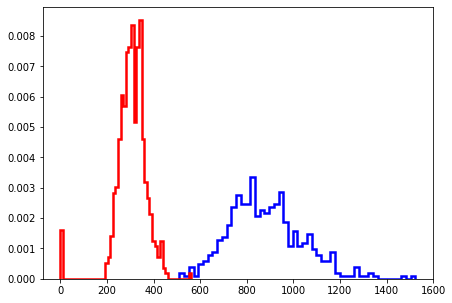

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
_, _, _ = ax.hist(q_gamma_bck, bins=50, histtype="step", lw=2.5, color="b", density=True)
_, _, _ = ax.hist(q_gamma_s, bins=50, histtype="step", lw=2.5, color="r", density=True)

In [93]:
#This is my observation - only background
nBDs=100; relT_R=0.10; relM_R=0.10; relR_R=0.10; relA_R=0.10
robs_R, Tobs_R, mass_R, ages_R = mock_population_all(nBDs, relT_R, relM_R, relR_R, relA_R,
                                         0, 1., 1., 
                                         rho0_true=rho0, 
                                         v=None)

xi         = np.transpose(np.asarray([ages_R, mass_R]))                            
Teff       = griddata(points, values, xi)                                        
heat_int_R = heat(Teff, np.ones(len(Teff))*R_jup.value)

In [168]:
# Asumme a given gamma
gamma       = 1.

def UL(gamma, Tobs_R, robs_R, mass_R, heat_int_R, relT_R):
    # Calculate TS_obs
    q_gamma_obs = TS(gamma, 1., 5., Tobs_R, robs_R, mass_R, heat_int_R, relT_R)
    
    # Construct pdf of TS for signal + background
    steps       = 200
    q_gamma_s   = np.ones(steps)
    path   = "/home/mariacst/exoplanets/exoplanets/data/"
    data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
    points = np.transpose(data[0:2, :])
    values = data[2]
    # Should I add noise in the generation of toy Monte Carlo experiments???
    nBDs=100; relT=0.1; relM=0.1; relR=0.1; relA=0.1
    for i in range(steps):
        robs, Tobs, mass, ages = mock_population_all(nBDs, relT, relM, relR, relA,
                                                 1., gamma, 5., 
                                                 rho0_true=rho0, 
                                                 v=None)    
        xi       = np.transpose(np.asarray([ages, mass]))                            
        Teff     = griddata(points, values, xi)                                        
        heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
        
        q_gamma_s[i] = TS(gamma, 1., 5., Tobs, robs, mass, heat_int, relT, rho0=0.42, v=None)
        
    counts, bins_ed, _ = ax.hist(q_gamma_s, bins=50, histtype="step", lw=2.5, color="r", density=True)
    
    pos = np.where(bins_ed > q_gamma_obs)
    _p = 0
    for i in range(len(pos[0])):
        _p += counts[-1-i]*(bins[1] + bins[0])
    #if np.abs(_p-0.05) < 0.01:
    #    break
    return _p, counts, bins_ed

In [171]:
gamma   = np.linspace(0.5, 1., 15)
p       = []
counts  = [] 
bins_ed = []

for g in gamma:
    _p, _c, _b = UL(g, Tobs_R, robs_R, mass_R, heat_int_R, relT_R)
    p.append(_p)
    counts.append(_c)
    bins_ed.append(_b)
    print(g, _p)
    if _p < 0.05:
        break

0.5 1.2339245278179403
0.5357142857142857 0.9124201573208439
0.5714285714285714 0.631829981691125
0.6071428571428571 0.2861507592688307
0.6428571428571428 0.4449823350783776
0.6785714285714286 0.46772999830686246
0.7142857142857143 0.18320843381240806
0.75 0.08857881112053015
0.7857142857142857 0.1350283164837967
0.8214285714285714 0.1092093937267057
0.8571428571428571 0.03624429209945426
0.8928571428571428 0
0.9285714285714286 0


KeyboardInterrupt: 

In [122]:
from scipy.stats import chi2
def half_chi2(q):
    if q==0:
        return (0.5 + chi2.pdf(q, 1))
    else:
        return (chi2.pdf(q, 1))
    
#def half_chi2(q):
#    return (np.heaviside(-q, 0.5) + chi2(q, 1))

q    = np.linspace(0, 8, 100)
f_th = [half_chi2(_q) for _q in q]

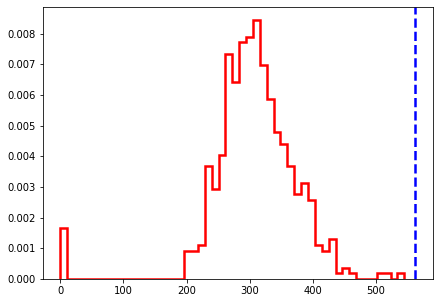

In [137]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

#ax.plot(q, f_th, color="k", ls=":", lw=2.5)

ax.axvline(q_gamma_obs, ls="--", color="blue", lw=2.5)
counts, bins_ed, _ = ax.hist(q_gamma_s, bins=50, histtype="step", lw=2.5, color="r", density=True)

**Final tentative**

For this part:

\begin{equation}
\ln\mathcal{L}_{s+b}(\gamma, r_s, f) \propto -\frac{1}{2\sigma_T^2}\sum_{i=1}^{N}\frac{\left(T_{DM, i}(\gamma, r_s, f)+T_{int, i}-T_{obs, i}\right)^2}{T_{obs, i}^2}
\end{equation}

and 

\begin{equation}
\ln\mathcal{L}_{b} \propto -\frac{1}{2\sigma_T^2}\sum_{i=1}^{N}\frac{\left(T_{int, i}-T_{obs, i}\right)^2}{T_{obs, i}^2}
\end{equation}


But the test statistics is given by:

\begin{equation}
TS = q_\gamma = 
-2\ln\left(\frac{\mathcal{L}_{s+b}(\gamma, \hat{\hat{f}})}{\mathcal{L}_b}\right)
\end{equation}

In [2]:
def lnL_sb(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    """
    Return ln(L) assuming predicted temperature = DM + intrinsic
    """  
    # Calculate predicted temperature (DM + intrinsic)
    T = temperature_withDM(robs, heat_int, f=f, M=Mobs*M_sun.value, parameters=[gamma, rs, rho0], v=v)
    # return
    return -0.5*np.sum(((T-Tobs)/(relT*Tobs))**2.) 

def lnL_b(Tobs, heat_int, relT):
    """
    Return ln(L) assuming predicted temperature = intrinsic
    """  
    # Calculate predicted intrinsic temperature
    T = temperature(heat_int, R_jup.value).value
    # return
    return -0.5*np.sum(((T-Tobs)/(relT*Tobs))**2.) 


def _lnL_sb_minimizer(p, gamma, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    """
    Return -2ln(L) (assumes Temperature = DM + intrinsic)
    """
    # free parameters of the fitting  
    f = p["f"]
    # Calculate predicted Temperature (DM + intrinsic)
    T = temperature_withDM(robs, heat_int, f=f, M=Mobs*M_sun.value, parameters=[gamma, rs, rho0], v=v)
    # return
    return ((T-Tobs)/(relT*Tobs))**2.

In [3]:
def TS(gamma, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    """
    Test statistics
    """
    params = Parameters()
    params.add("f", value=0.5, min=0., max=1.)
    out = minimize(_lnL_sb_minimizer, params, args=(gamma, rs, Tobs, robs, Mobs, heat_int, relT))
    assert out.success == True, "MLE gamma could not be found!"
    f_ML = out.params["f"].value
    #print("f_ML = ", f_ML)
    # return
    return (-2.*lnL_sb(gamma, f_ML, rs, Tobs, robs, Mobs, heat_int, relT)-2*lnL_b(Tobs, heat_int, relT))

Compute pdf for TS

In [13]:
def p_value(gamma_k, f, rs, Tobs_R, robs_R, Mobs_R, heat_int_R, relT_R, steps=200):
    """
    Return p-value and TS pdf for gamma_k @ (f, rs)
    """
    # Find the MLE of f in observation
    params = Parameters()
    params.add("f", value=0.5, min=0., max=1.)
    out = minimize(_lnL_sb_minimizer, params, args=(gamma_k, rs, Tobs_R, robs_R, Mobs_R, heat_int_R, relT_R))
    assert out.success == True, "MLE gamma could not be found!"
    f_ML_obs = out.params["f"].value
    print("f_ML_obs = ", f_ML_obs)
    # Compute TS pdf
    TS_k  = np.zeros(steps)
    # Load ATMO2020 model
    path   = "/home/mariacst/exoplanets/exoplanets/data/"
    data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
    points = np.transpose(data[0:2, :])
    values = data[2]
    for i in range(steps):
        # Generate mock data sample under the assumption of gamma_k and f_ML_obs
        robs, Tobs, Mobs, ages = mock_population_all(nBDs, relT_R, relM_R, relR_R, relA_R,
                                                     f_ML_obs, gamma_k, rs)
        # Predicted intrinsic temperatures
        xi       = np.transpose(np.asarray([ages, Mobs]))                            
        Teff     = griddata(points, values, xi)                                        
        heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)   
        # TS
        TS_k[i] = TS(gamma_k, f, rs, Tobs, robs, Mobs, heat_int, relT_R)
    # TS pdf @ gamma_k
    counts, bins_ed, _ = plt.hist(TS_k, bins=50, density=True)
    # observed TS
    q_gamma_k_obs = TS(gamma_k, f, rs, Tobs_R, robs_R, Mobs_R, heat_int_R, relT_R)
    # Compute p-value
    pos = np.where(bins_ed > q_gamma_k_obs)
    _p = 0
    for i in range(len(pos[0])):
        _p += counts[-1-i]*(bins_ed[1] + bins_ed[0])
    # return
    return _p, counts, bins_ed

*Real* observation - only background

In [14]:
nBDs=100; relT_R=0.10; relM_R=0.10; relR_R=0.10; relA_R=0.10
rho0=0.42
# Load ATMO2020 model
path   = "/home/mariacst/exoplanets/exoplanets/data/"
data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
points = np.transpose(data[0:2, :])
values = data[2]
    
robs_R, Tobs_R, mass_R, ages_R = mock_population_all(nBDs, relT_R, relM_R, relR_R, relA_R,
                                         0, 1., 1., 
                                         rho0_true=rho0, 
                                         v=None)

xi         = np.transpose(np.asarray([ages_R, mass_R]))                            
Teff       = griddata(points, values, xi)                                        
heat_int_R = heat(Teff, np.ones(len(Teff))*R_jup.value)

f_ML_obs =  0.4141606863393824
0.0 53.38317331646079
f_ML_obs =  0.28984537187692533
0.10714285714285714 62.792146196792295
f_ML_obs =  0.2017796143561405
0.21428571428571427 55.526051995860584
f_ML_obs =  0.1409915906912168
0.3214285714285714 58.48550321308226
f_ML_obs =  0.0988542276623326


KeyboardInterrupt: 

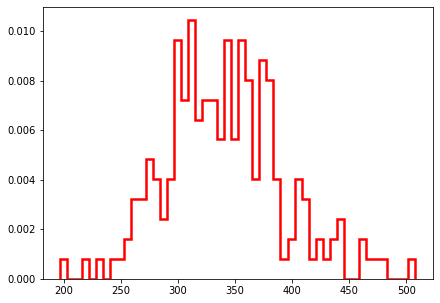

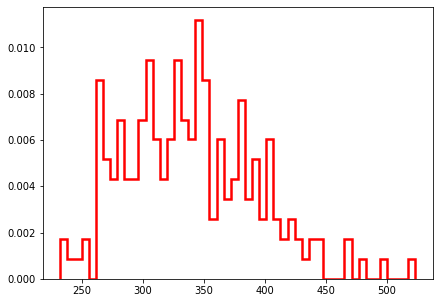

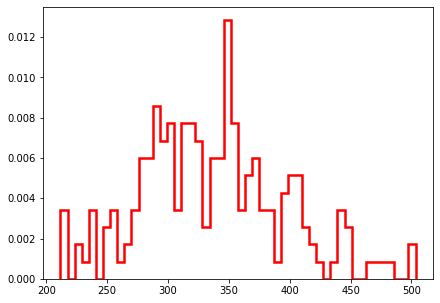

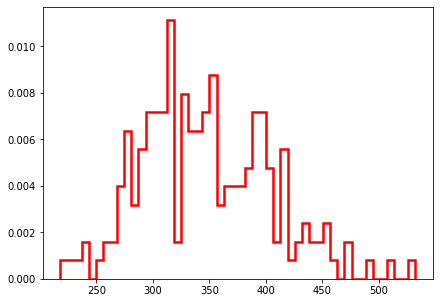

In [15]:
gamma_k = np.linspace(0., 1.5, 15)
rs      = 5.
p       = []
counts  = [] 
bins_ed = []

for g in gamma_k:
    _p, _c, _b = p_value(g, rs, Tobs_R, robs_R, mass_R, heat_int_R, relT_R)
    p.append(_p)
    counts.append(_c)
    bins_ed.append(_b)
    print(g, _p)
    if _p < 0.05:
        break

The problem is that $\hat{\hat{f}}(\gamma)\sim 0$, therefore $\mathcal{L_{s+b}} --> \mathcal{L_{b}}$ and $\gamma$ is not really influencing the results. We are not able to set an UL! 

Solution: calculate UL for given value of $f$

In [33]:
def lnL_sb(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    """
    Return ln(L) assuming predicted temperature = DM + intrinsic
    """  
    # Calculate predicted temperature (DM + intrinsic)
    T = temperature_withDM(robs, heat_int, f=f, M=Mobs*M_sun.value, 
                           parameters=[gamma, rs, rho0], v=v)
    # return
    return -0.5*np.sum(((T-Tobs)/(relT*Tobs))**2.) 

def lnL_b(Tobs, heat_int, relT):
    """
    Return ln(L) assuming predicted temperature = intrinsic
    """  
    # Calculate predicted intrinsic temperature
    T = temperature(heat_int, R_jup.value).value
    # return
    return -0.5*np.sum(((T-Tobs)/(relT*Tobs))**2.) 

def _lnL_sb_minimizer(p, gamma, rs, Tobs, robs, Mobs, heat_int, relT, 
                      rho0=0.42, v=None):
    """
    Return -2ln(L) (assumes Temperature = DM + intrinsic)
    """
    # free parameters of the fitting  
    f = p["f"]
    # Calculate predicted Temperature (DM + intrinsic)
    T = temperature_withDM(robs, heat_int, f=f, M=Mobs*M_sun.value, 
                           parameters=[gamma, rs, rho0], v=v)
    # return
    return ((T-Tobs)/(relT*Tobs))**2.

def TS(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT, rho0=0.42, v=None):
    """
    Test statistics
    """
    # return
    return (-2.*lnL_sb(gamma, f, rs, Tobs, robs, Mobs, heat_int, relT, rho0, v)
            -2*lnL_b(Tobs, heat_int, relT))


def p_value(gamma_k, f, rs, Tobs_R, robs_R, Mobs_R, heat_int_R, relT_R, 
            steps=300):
    """
    Return p-value and TS pdf for gamma_k @ (f, rs)
    """
    # Find the MLE of f in observation
    params = Parameters()
    params.add("f", value=0.5, min=0., max=1.)
    out = minimize(_lnL_sb_minimizer, params, 
                   args=(gamma_k, rs, Tobs_R, robs_R, Mobs_R, heat_int_R, relT_R))
    assert out.success == True, "MLE gamma could not be found!"
    f_ML_obs = out.params["f"].value
    #print("f_ML_obs = ", f_ML_obs)
    # Compute TS pdf
    TS_k  = np.zeros(steps)
    # Load ATMO2020 model
    path   = "/home/mariacst/exoplanets/exoplanets/data/"
    data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
    points = np.transpose(data[0:2, :])
    values = data[2]
    
    for i in range(steps):
        # Generate mock data sample under the assumption of gamma_k and f_ML_obs
        robs, Tobs, Mobs, ages = mock_population_all(nBDs, relT_R, relM_R, relR_R, 
                                         relA_R, f_ML_obs, gamma_k, rs)
        # Predicted intrinsic temperatures
        xi       = np.transpose(np.asarray([ages, Mobs]))
        Teff     = griddata(points, values, xi)
        heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
        # TS
        TS_k[i] = TS(gamma_k, f, rs, Tobs, robs, Mobs, heat_int, relT_R)
    # TS pdf @ gamma_k
    counts, bins_ed, _ = plt.hist(TS_k, bins=50, density=True)
    # observed TS
    q_gamma_k_obs = TS(gamma_k, f, rs, Tobs_R, robs_R, Mobs_R, heat_int_R, relT_R)
    # Compute p-value
    pos = np.where(bins_ed > q_gamma_k_obs)
    _p = 0
    for i in range(len(pos[0])):
        _p += counts[-1-i]*(bins_ed[1] + bins_ed[0])
    # return
    return _p, counts, bins_ed, TS_k, q_gamma_k_obs

In [34]:
# Generate "real" observation assuming only background (no DM)
nBDs=100; relT_R=0.10; relM_R=0.10; relR_R=0.10; relA_R=0.10
rho0=0.42
# Load ATMO2020 model
path   = "/home/mariacst/exoplanets/exoplanets/data/"
data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
points = np.transpose(data[0:2, :])
values = data[2]
np.random.seed(42) # ========= reproducable results!
robs_R, Tobs_R, mass_R, ages_R = mock_population_all(nBDs, relT_R, relM_R, 
                                     relR_R, relA_R,
                                     0, 1., 1., rho0_true=rho0, v=None)
xi         = np.transpose(np.asarray([ages_R, mass_R]))
Teff       = griddata(points, values, xi)
heat_int_R = heat(Teff, np.ones(len(Teff))*R_jup.value)

0.0 60.35502009061481


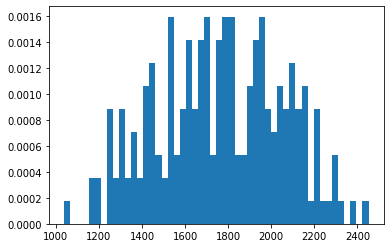

In [39]:
steps    = 200
f        = 1.
rs       = 5.
gamma_k  = np.linspace(0, 1.5, 10) 


for g in gamma_k:
    _p, _c, _b, TS_k, TS_obs = p_value(1.5, f, rs, Tobs_R, robs_R, mass_R, heat_int_R, relT_R, 
                        steps=steps)
    print(g, _p)
    break
    if _p < 0.05:
        gamma_up[i] = g
        p_up[i]     = _p
        print(rs[i], g, _p)
        break

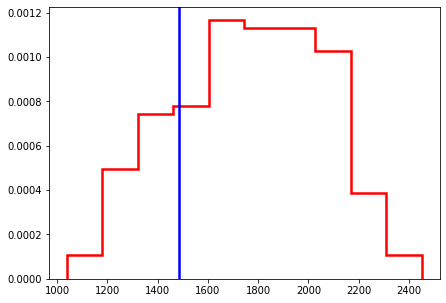

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
_, _, _ = ax.hist(TS_k, color="r", lw=2.5, histtype="step", density=True)
ax.axvline(TS_obs, color="blue", ls="-", lw=2.5)

# Current upper limits

In [5]:
import astropy.units as u
from astropy.constants import M_sun, M_jup

print(6*M_jup/M_sun)
print(75*M_jup/M_sun)
print(0.014022959220645633*M_sun/M_jup, 0.05801506259606878*M_sun/M_jup)

0.00572756540381595
0.07159456754769937
14.689968493038528 60.7745789065106


In [2]:
rs = [5., 10., 15., 20., 30]
gamma_UL_asi = [0.1379, 0.4655, 0.5828, 0.6517, 0.7207]
gamma_UL_5   = np.genfromtxt("../python/data_UL/UL_fixedT10v100_nBDs100_f1.0_steps200_sigma0.1_rs5.0.dat")
gamma_UL_10  = np.genfromtxt("../python/data_UL/UL_fixedT10v100_nBDs100_f1.0_steps200_sigma0.1_rs10.0.dat")
gamma_UL_15  = np.genfromtxt("../python/data_UL/UL_fixedT10v100_nBDs100_f1.0_steps200_sigma0.1_rs15.0.dat")
gamma_UL_20  = np.genfromtxt("../python/data_UL/UL_fixedT10v100_nBDs100_f1.0_steps200_sigma0.1_rs20.0.dat")
gamma_UL_30  = np.genfromtxt("../python/data_UL/UL_fixedT10v100_nBDs100_f1.0_steps200_sigma0.1_rs30.0.dat")

print(len(gamma_UL_5), len(gamma_UL_10), len(gamma_UL_15), len(gamma_UL_20),len(gamma_UL_30))

400 300 250 199 400


In [3]:
pos = np.where(gamma_UL_5>0.001)
print(len(pos[0]))

269


10.0 0.4655 0.4488
15.0 0.5828 0.5798


Text(0.5, 0, '$\\gamma$')

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


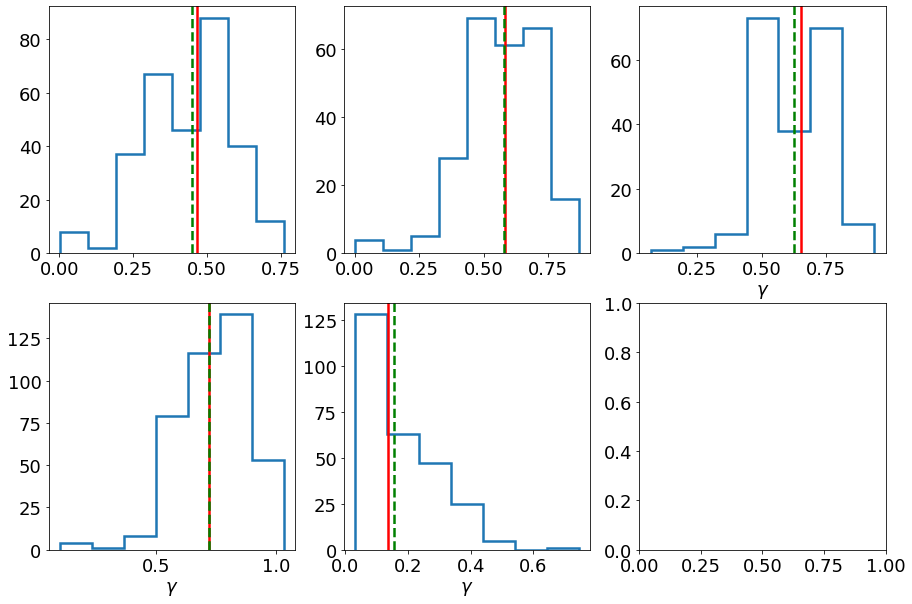

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0, 0].hist(gamma_UL_10, bins=8, histtype="step", lw=2.5);
ax[0, 0].axvline(gamma_UL_asi[1], color="red", lw=2.5, label="Asimov")
ax[0, 0].axvline(np.median(gamma_UL_10), color="green", ls="--", lw=2.5, label="median")
print(rs[1], gamma_UL_asi[1], np.median(gamma_UL_10))
#ax[0].legend()
#ax[0].set_ylabel("counts")
#ax[0].set_xlabel(r"$\gamma$")

ax[0, 1].hist(gamma_UL_15, bins=8, histtype="step", lw=2.5);
ax[0, 1].axvline(gamma_UL_asi[2], color="red", lw=2.5, label="Asimov")
ax[0, 1].axvline(np.median(gamma_UL_15), color="green", ls="--", lw=2.5, label="median")
print(rs[2], gamma_UL_asi[2], np.median(gamma_UL_15))

ax[0, 2].hist(gamma_UL_20, bins=7, histtype="step", lw=2.5);
ax[0, 2].axvline(gamma_UL_asi[3], color="red", lw=2.5)
ax[0, 2].axvline(np.median(gamma_UL_20), color="green", ls="--", lw=2.5)
ax[0, 2].set_xlabel(r"$\gamma$")

ax[1, 0].hist(gamma_UL_30, bins=7, histtype="step", lw=2.5);
ax[1, 0].axvline(gamma_UL_asi[4], color="red", lw=2.5)
ax[1, 0].axvline(np.median(gamma_UL_30), color="green", ls="--", lw=2.5)
ax[1, 0].set_xlabel(r"$\gamma$")

ax[1, 1].hist(gamma_UL_5[pos], bins=7, histtype="step", lw=2.5);
ax[1, 1].axvline(gamma_UL_asi[0], color="red", lw=2.5)
ax[1, 1].axvline(np.median(gamma_UL_5[pos]), color="green", ls="--", lw=2.5)
ax[1, 1].set_xlabel(r"$\gamma$")

In [3]:
rs = [5., 10., 15., 20., 30.]
gamma_UL_1sigma_minus = np.ones(len(rs))*100.; gamma_UL_1sigma_plus  = np.ones(len(rs))*100.
gamma_UL_2sigma_minus = np.ones(len(rs))*100.; gamma_UL_2sigma_plus  = np.ones(len(rs))*100.
i = 0
for _rs in rs:
    gamma_UL = np.genfromtxt("../python/data_UL/UL_fixedT10v100_nBDs100_f1.0_steps200_sigma0.1_rs%.1f.dat" %_rs)
    gamma_UL_2sigma_minus[i] = np.percentile(gamma_UL, 2.5)
    gamma_UL_1sigma_minus[i] = np.percentile(gamma_UL, 16)
    gamma_UL_1sigma_plus[i]  = np.percentile(gamma_UL, 84)
    gamma_UL_2sigma_plus[i]  = np.percentile(gamma_UL, 97.5)
    
    i+=1

In [4]:
print(gamma_UL_2sigma_minus, gamma_UL_2sigma_plus)

[0.001   0.08624 0.2491  0.3803  0.4724 ] [0.4041575 0.7244    0.8279    0.8741    0.969    ]


'texgyreheros-regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.


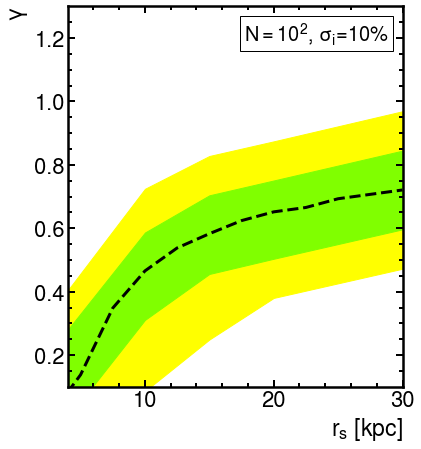

In [18]:
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2.5 #set the value globally

fig, ax = plt.subplots(1, 1, figsize=(6, 7))

path="../python/data_UL/"

ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
#ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax.plot(data[0], data[1], color="k", lw=3., ls="--")

rs = [4., 10., 15., 20., 30.]
ax.fill_between(rs, gamma_UL_2sigma_minus, y2=gamma_UL_1sigma_minus, color="#ffff00")
ax.fill_between(rs, gamma_UL_1sigma_plus, y2=gamma_UL_2sigma_plus, color="#ffff00")
ax.fill_between(rs, gamma_UL_1sigma_minus, y2=gamma_UL_1sigma_plus, color="#80ff00")

#ax.text(10, 1.1, "nBDs=%i, f=1, $\sigma=$10"%(nBDs)+"$\%$",color=line_col,fontsize=small_fs,rotation=10)


ax.set_ylabel(r"$\gamma$", fontsize=23); ax.set_xlabel(r"$r_s$ [kpc]", fontsize=23)
ax.set_ylim(0.1, 1.3); ax.set_xlim(4., 30.)

from matplotlib.offsetbox import AnchoredText
text_box = AnchoredText((r"$N=10^{%i}$, $\sigma_i$=%i"                      
                            %(int(np.log10(nBDs)), int(sigma*100))            
                            + "$\% $"),                                         
                            frameon=True, loc=1, pad=0.2, prop=dict(size=20))   
plt.setp(text_box.patch, facecolor="white")                                 
ax.add_artist(text_box)  

plt.setp(ax.get_xticklabels(), fontsize=22)
plt.setp(ax.get_yticklabels(), fontsize=22)

ax.tick_params(which='major',direction="in",width=2.,length=7,right=True,top=True,pad=3)
ax.tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=True)

fig.savefig("BrazilBand_" + ex + "_nBDs%i_sigma%.1f.pdf" %(nBDs, sigma), bbox_inches="tight")

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


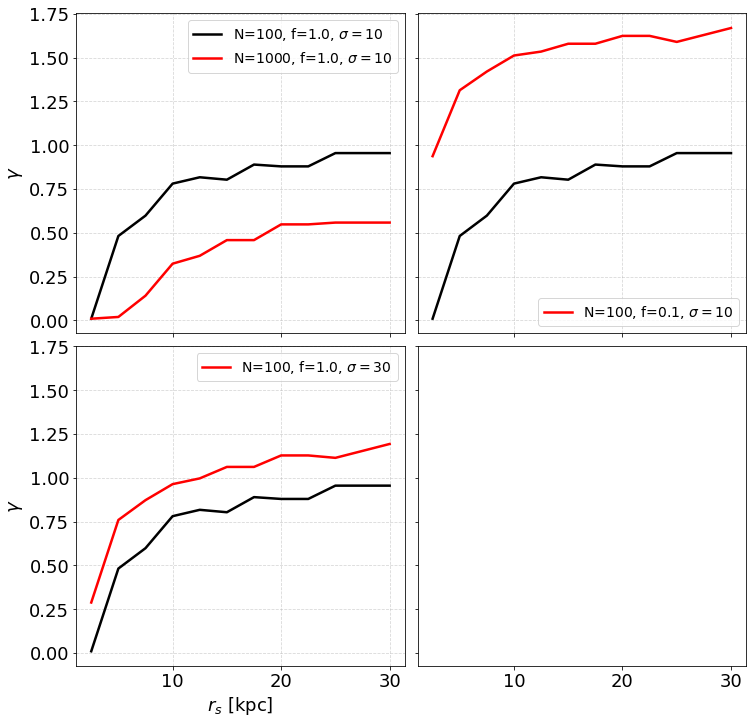

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

sigma = 0.1
nBDs  = [100, 1000]
f     = [0.1, 1]
color = ["blue", "orange"]
ls    = ["-", "--"]

data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" %(100, 1., 0.1), unpack=True)
ax[0, 0].plot(data[0], data[1], color="k", lw=2.5, ls="-", 
              label=r"N=%i, f=%.1f, $\sigma=$%i" %(100, 1, 10))
ax[0, 1].plot(data[0], data[1], color="k", lw=2.5, ls="-")
ax[1, 0].plot(data[0], data[1], color="k", lw=2.5, ls="-")

data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" %(1000, 1., 0.1), unpack=True)
ax[0, 0].plot(data[0], data[1], color="r", lw=2.5, ls="-", 
              label=r"N=%i, f=%.1f, $\sigma=$%i" %(1000, 1, 10))

data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" %(100, 0.1, 0.1), unpack=True)
ax[0, 1].plot(data[0], data[1], color="r", lw=2.5, ls="-", 
              label=r"N=%i, f=%.1f, $\sigma=$%i" %(100, 0.1, 10))

data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" %(100, 1, 0.3), unpack=True)
ax[1, 0].plot(data[0], data[1], color="r", lw=2.5, ls="-", 
              label=r"N=%i, f=%.1f, $\sigma=$%i" %(100, 1, 30))


ax[0, 0].legend(fontsize=14); ax[0, 1].legend(fontsize=14); ax[1, 0].legend(fontsize=14)
ax[0, 0].set_ylabel(r"$\gamma$"); ax[1, 0].set_xlabel("$r_s$ [kpc]"); ax[1, 0].set_ylabel(r"$\gamma$");
ax[0, 0].grid(ls="--", alpha=0.5); ax[0, 1].grid(ls="--", alpha=0.5); ax[1, 0].grid(ls="--", alpha=0.5)

plt.subplots_adjust(hspace=0.04, wspace=0.04)


Text(0.5, 0, '$r_s$ [kpc]')

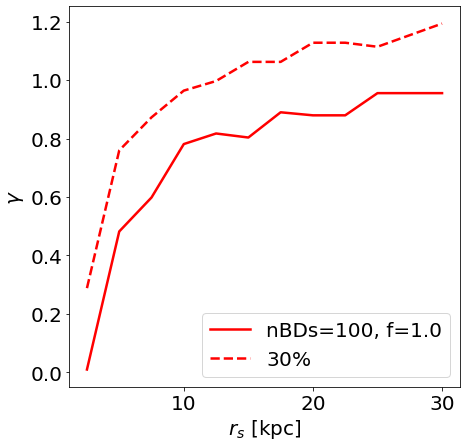

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

sigma = 0.1
nBDs  = [100]
f     = [1]
color = ["blue", "orange"]
ls    = ["-", "--"]

for i in range(len(nBDs)):
    for j in range(len(f)):
        data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                                 %(nBDs[i], f[j], 0.1), unpack=True)
        ax.plot(data[0], data[1], color="red", lw=2.5, ls=ls[j], label=r"nBDs=%i, f=%.1f" 
                %(nBDs[i], f[j]))
        data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                                 %(nBDs[i], f[j], 0.3), unpack=True)
        ax.plot(data[0], data[1], color="red", lw=2.5, ls="--", label=r"30$\%$")

ax.legend()
ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")

Text(0.5, 0, '$r_s$ [kpc]')

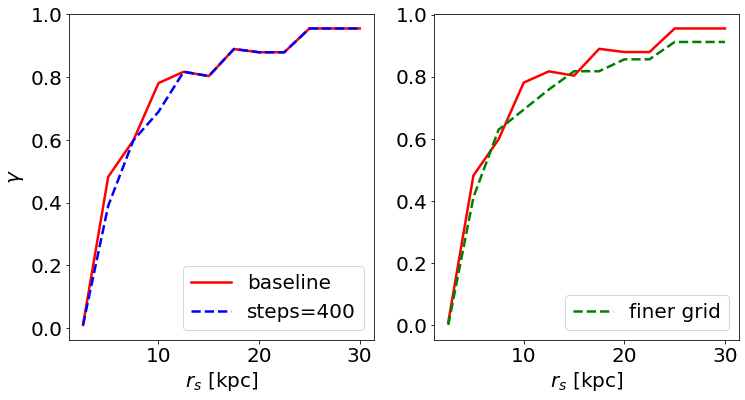

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sigma = 0.1
nBDs  = 100
f     = 1

data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                     %(nBDs, f, sigma), unpack=True)
ax[0].plot(data[0], data[1], color="red", lw=2.5, ls="-", label="baseline")
ax[1].plot(data[0], data[1], color="red", lw=2.5, ls="-")

data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps%i_sigma%.1f_Asimov.dat" 
                     %(nBDs, f, 400, sigma), unpack=True)
ax[0].plot(data[0], data[1], color="blue", lw=2.5, ls="--", label="steps=400")

data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov_finer.dat" 
                     %(nBDs, f, sigma), unpack=True)
ax[1].plot(data[0], data[1], color="green", lw=2.5, ls="--", label="finer grid")

ax[0].legend(); ax[1].legend()
ax[0].set_ylabel(r"$\gamma$"); ax[0].set_xlabel("$r_s$ [kpc]"); ax[1].set_xlabel("$r_s$ [kpc]")

Text(0.5, 0, '$r_s$ [kpc]')

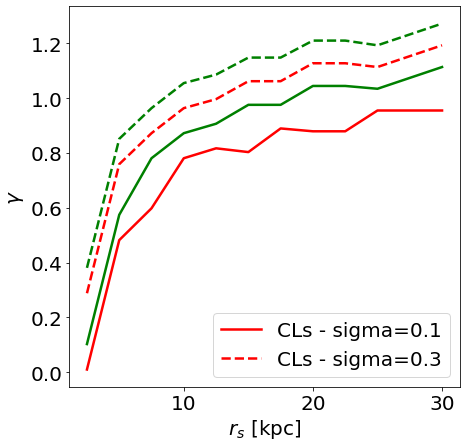

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

sigma = [0.1, 0.3]
nBDs  = 100
f     = 1
color = ["blue", "orange"]
ls    = ["-", "--"]

for j in range(len(sigma)):
    data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                             %(nBDs, f, sigma[j]), unpack=True)
    ax.plot(data[0], data[1], color="red", lw=2.5, ls=ls[j], label="CLs - sigma=%.1f" %sigma[j])
    try:
        data = np.genfromtxt("../python/data_UL/UL_nBDs%i_f%.1f_steps200_Asimov_sigma%.1f_CLsb.dat" 
                             %(nBDs, f, sigma[j]), unpack=True)
        ax.plot(data[0], data[1], color="green", lw=2.5, ls=ls[j])
    except:
        continue

ax.legend()
ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")

In [2]:
def plot_UL(ax, ex, nBDs, sigma, f, color="red", ls="-", path="../python/data_UL/"):
    data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
    ax.plot(data[0], data[1], color=color, lw=2.5, ls=ls, label="nBDs=%i, sigma=%.1f, f=%.1f" 
            %(nBDs, sigma, f))
    # return
    return

In [3]:
def FigSetup(lw=2.5,lfs=40,tfs=25,tickdir='out',
             Grid=False,Shape='Square',mathpazo=False,
             TopAndRightTicks=False):

        plt.rcParams['axes.linewidth'] = lw
        plt.rc('text', usetex=False)
        plt.rc('font', family='serif',size=tfs)

        if mathpazo:
            mpl.rcParams['text.latex.preamble'] = [r'\usepackage{mathpazo}']

        if Shape=='Wide':
            fig = plt.figure(figsize=(16.5,5))
        elif Shape=='Rectangular':
            fig = plt.figure(figsize=(16.5,11))
        elif Shape=="Square":
            fig = plt.figure(figsize=(8,8))

        ax = fig.add_subplot(111)

        ax.tick_params(which='major',direction=tickdir,width=2.5,length=13,right=TopAndRightTicks,top=TopAndRightTicks,pad=7)
        ax.tick_params(which='minor',direction=tickdir,width=1,length=10,right=TopAndRightTicks,top=TopAndRightTicks)

        ax.set_xlim(2.5, 30); ax.set_ylim(0.1, 2.)
        
        #locmaj = mpl.ticker.LogLocator(base=10.0, subs=(1.0, ), numticks=50)
        #locmin = mpl.ticker.LogLocator(base=10.0, subs=arange(2, 10)*.1,numticks=100)
        #ax.xaxis.set_major_locator(locmaj)
        #ax.xaxis.set_minor_locator(locmin)
        #ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())

        #locmaj = mpl.ticker.LogLocator(base=10.0, subs=(1.0, ), numticks=100)
        #locmin = mpl.ticker.LogLocator(base=10.0, subs=arange(2, 10)*.1,numticks=100)
        #ax.yaxis.set_major_locator(locmaj)
        #ax.yaxis.set_minor_locator(locmin)
        #ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

        if Shape=='Rectangular':
            plt.xticks(rotation=20)

        if Grid:
            ax.grid(zorder=0)

        return fig, ax

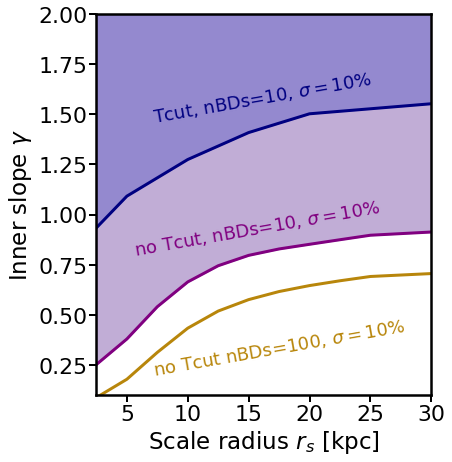

In [37]:
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2.5 #set the value globally

fig, ax = plt.subplots(1, 1, figsize=(6, 7))

#plt.rcParams['axes.linewidth'] = 2.5
#plt.rc('text', usetex=False)
#plt.rc('font', family='serif',size=25)

#ax.tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)

path="../python/data_UL/"

line_col = 'navy'
col = 'royalblue'

zo = 0.01; smooth=1.2; small_fs=18

ex="fixedT10v100Tcut650_nocutTwn"; nBDs=10; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax.text(7, 1.46, "Tcut, nBDs=%i, $\sigma=$10"%(nBDs)+"$\%$",color=line_col,fontsize=small_fs,rotation=10)

line_col = 'purple'
col = 'rebeccapurple'

ex="fixedT10v100"; nBDs=10; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
#ax.text(10, 1.1, "nBDs=%i, f=1, $\sigma=$10"%(nBDs)+"$\%$",color=line_col,fontsize=small_fs,rotation=10)
ax.text(5.5, 0.8, "no Tcut, nBDs=%i, $\sigma=$10"%(nBDs)+"$\%$",color=line_col,fontsize=small_fs,rotation=10)


col = 'goldenrod'
line_col = 'darkgoldenrod'

ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
#ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax.text(7., 0.2, "no Tcut nBDs=%i, $\sigma=10$" %(nBDs)+"$\%$",color=line_col,fontsize=small_fs,rotation=10)


ax.set_ylabel(r"Inner slope $\gamma$", fontsize=23); ax.set_xlabel(r"Scale radius $r_s$ [kpc]", fontsize=23)
ax.set_ylim(0.1, 2.); ax.set_xlim(2.5, 30.)

plt.setp(ax.get_xticklabels(), fontsize=22)
plt.setp(ax.get_yticklabels(), fontsize=22)

ax.tick_params(which='major',direction="out",width=2.,length=7,right=False,top=False,pad=2)
ax.tick_params(which='minor',direction="out",width=2.,length=7,right=False,top=False, pad=2)

fig.savefig("BDsensitivity_nBDs10_Tcut_woTcut.pdf", bbox_inches="tight")

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


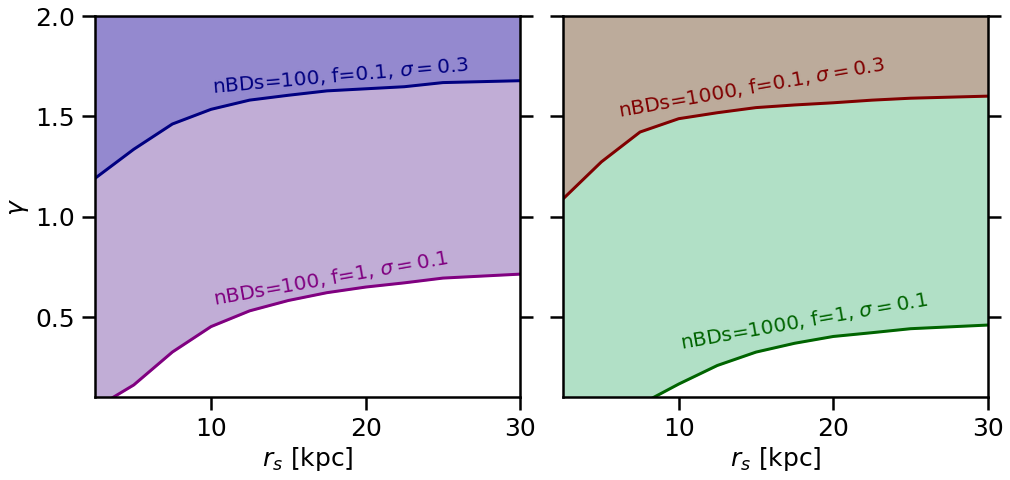

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

plt.rcParams['axes.linewidth'] = 2.5
plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=25)

ax[0].tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)
ax[1].tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)


path="../python/data_UL/"

line_col = 'navy'
col = 'royalblue'

zo = 0.01; smooth=0.8; small_fs=20

ex="fixedT10v100"; nBDs=100; f=0.1; sigma=0.3
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[0].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[0].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[0].text(10,1.62, "nBDs=%i, f=0.1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=5)

line_col = 'purple'
col = 'rebeccapurple'

ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[0].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[0].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[0].text(10,0.56, "nBDs=%i, f=1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)

ax[0].set_ylabel(r"$\gamma$"); ax[0].set_xlabel("$r_s$ [kpc]")
ax[0].set_ylim(0.1, 2.); ax[0].set_xlim(2.5, 30.)

plt.subplots_adjust(wspace=0.1)


col = 'mediumseagreen'
line_col = 'darkgreen'

ex="fixedT10v100"; nBDs=1000; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[1].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[1].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[1].text(10, 0.34, "nBDs=%i, f=1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)

col = "indianred"#'orange'
line_col = "maroon"#'darkorange'

ex="fixedT10v100"; nBDs=1000; f=0.1; sigma=0.3
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[1].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[1].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[1].text(6, 1.5, "nBDs=%i, f=0.1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)
ax[1].set_xlim(2.5, 30.); ax[1].set_xlabel("$r_s$ [kpc]")

fig.savefig("sensitivity_fixedT10v100.png", bbox_inches="tight")

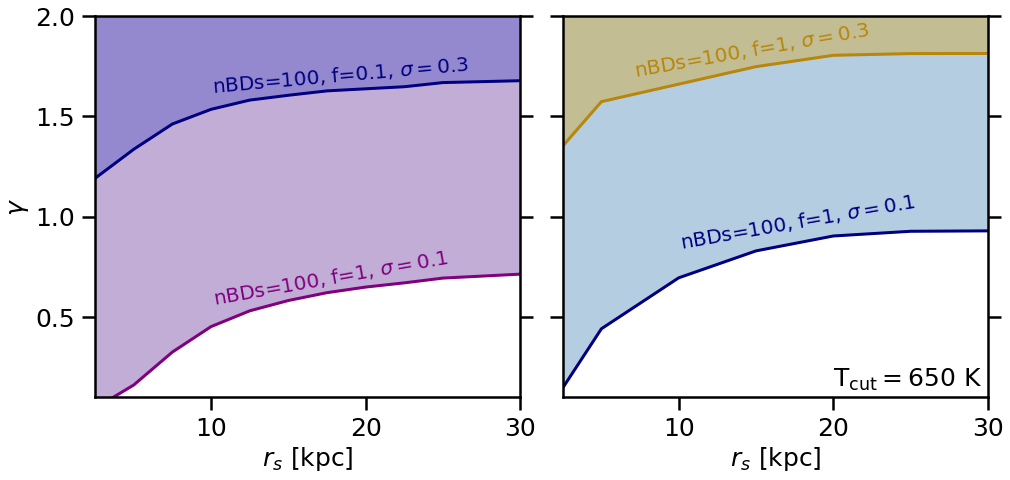

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

plt.rcParams['axes.linewidth'] = 2.5
plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=25)

ax[0].tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)
ax[1].tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)


path="../python/data_UL/"

line_col = 'navy'
col = 'royalblue'

zo = 0.01; smooth=0.8; small_fs=20

ex="fixedT10v100"; nBDs=100; f=0.1; sigma=0.3
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[0].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[0].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[0].text(10,1.62, "nBDs=%i, f=0.1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=5)

line_col = 'purple'
col = 'rebeccapurple'

ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[0].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[0].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[0].text(10,0.56, "nBDs=%i, f=1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)

ax[0].set_ylabel(r"$\gamma$"); ax[0].set_xlabel("$r_s$ [kpc]")
ax[0].set_ylim(0.1, 2.); ax[0].set_xlim(2.5, 30.)

plt.subplots_adjust(wspace=0.1)


col = 'steelblue'
line_col = 'navy'

ex="fixedT10v100Tcut650"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[1].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[1].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[1].text(10, 0.84, "nBDs=%i, f=1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)
ax[1].text(20, 0.15, r"T$_{\rm cut}=650$ K")

col = 'goldenrod'
line_col = 'darkgoldenrod'

ex="fixedT10v100Tcut650"; nBDs=100; f=0.1; sigma=0.3
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[1].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[1].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[1].text(7., 1.7, "nBDs=%i, f=1, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)

ax[1].set_xlim(2.5, 30.); ax[1].set_xlabel("$r_s$ [kpc]")

fig.savefig("sensitivity_fixedT10v100_vs_fixedT10v100Tcut650.pdf", bbox_inches="tight")

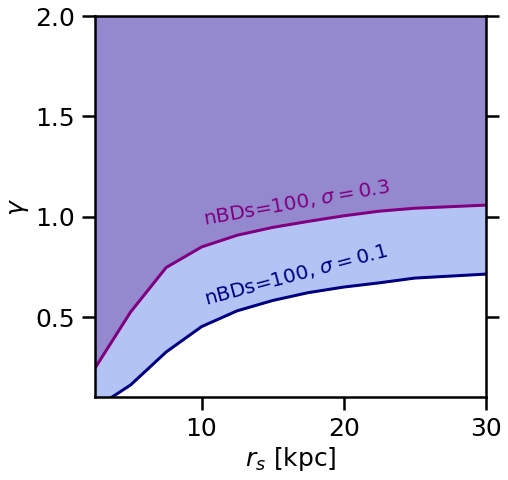

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharey=True)

plt.rcParams['axes.linewidth'] = 2.5
plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=25)


ax.tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)


path="../python/data_UL/"

line_col = 'navy'
col = 'royalblue'

zo = 0.01; smooth=0.8; small_fs=20

ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax.text(10,0.56, "nBDs=%i, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=15)
ax.set_ylim(0.1, 2.); ax.set_xlim(2.5, 30.)
ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")


plot="True"
if plot=="True":
    
        
    line_col = 'purple'
    col = 'rebeccapurple'
    
    ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.3
    data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                             %(nBDs, f, sigma), unpack=True)
    ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
    ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
    ax.text(10,0.96, "nBDs=%i, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)
    
        
    col = 'goldenrod'
    line_col = 'darkgoldenrod'
    
    ex="fixedT10v100"; nBDs=1000; f=1.; sigma=0.1
    data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                             %(nBDs, f, sigma), unpack=True)
    ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
    ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
    print(data[0])
    ax.text(9., 0.3, "nBDs=%i, $\sigma=%.1f$" %(nBDs, sigma),color=line_col,fontsize=small_fs,rotation=10)

fig.savefig("sensitivity_2.pdf", bbox_inches="tight")

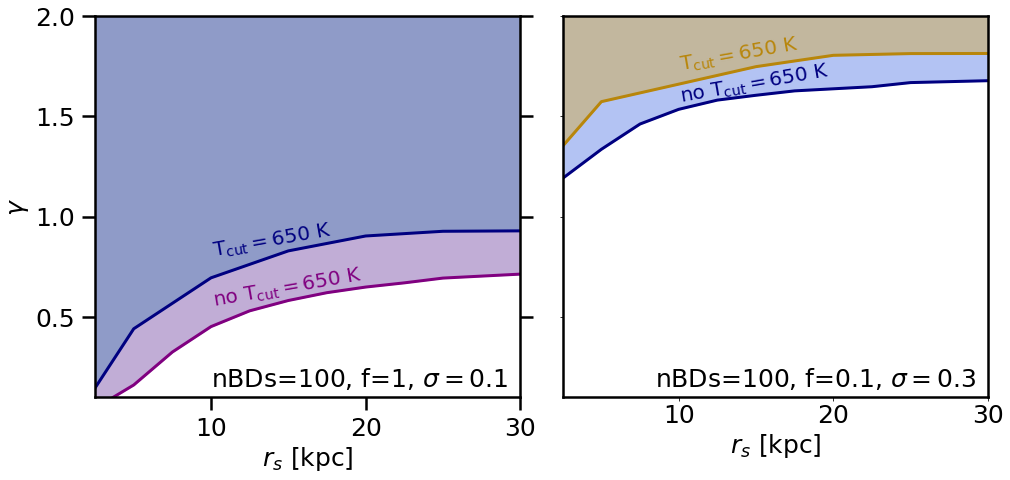

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

plt.rcParams['axes.linewidth'] = 2.5
plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=25)

ax[0].tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)

path="../python/data_UL/"

line_col = 'purple'
col = 'rebeccapurple'

ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[0].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[0].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[0].text(10, 0.55, r"no T$_{\rm cut}=650$ K", color=line_col,fontsize=small_fs,rotation=10)

col = 'steelblue'
line_col = 'navy'

ex="fixedT10v100Tcut650"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                       %(nBDs, f, sigma), unpack=True)
ax[0].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[0].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[0].text(10, 0.80, r"T$_{\rm cut}=650$ K", color=line_col,fontsize=small_fs,rotation=10)
ax[0].text(10, 0.15, "nBDs=%i, f=1, $\sigma=%.1f$"%(nBDs, sigma))

ax[0].set_ylabel(r"$\gamma$"); ax[0].set_xlabel("$r_s$ [kpc]")
ax[0].set_xlim(2.5, 30.); ax[0].set_ylim(0.1, 2.);



line_col = 'navy'
col = 'royalblue'

ex="fixedT10v100"; nBDs=100; f=0.1; sigma=0.3
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax[1].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[1].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[1].text(10, 1.57, r"no T$_{\rm cut}=650$ K", color=line_col,fontsize=small_fs,rotation=10)

col = 'goldenrod'
line_col = 'darkgoldenrod'

ex="fixedT10v100Tcut650"; nBDs=100; f=0.1; sigma=0.3
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                       %(nBDs, f, sigma), unpack=True)
ax[1].fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax[1].plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax[1].text(10, 1.73, r"T$_{\rm cut}=650$ K", color=line_col,fontsize=small_fs,rotation=10)
ax[1].text(8.5, 0.15, "nBDs=%i, f=0.1, $\sigma=%.1f$"%(nBDs, sigma))

ax[1].set_xlabel("$r_s$ [kpc]")
ax[1].set_xlim(2.5, 30.); ax[1].set_ylim(0.1, 2.);



plt.subplots_adjust(wspace=0.1)


fig.savefig("sensitivity_fixedT10v100_vs_fixedT10v100Tcut650_nBDs100f1.0sigma0.1.pdf", bbox_inches="tight")


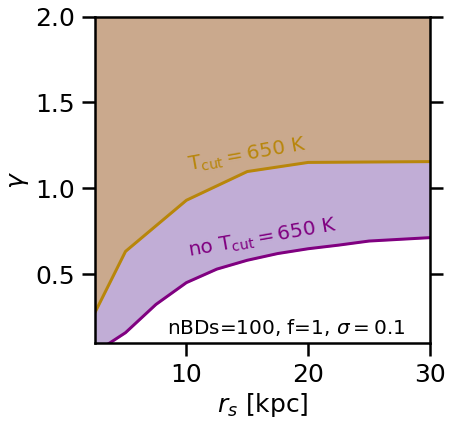

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

plt.rcParams['axes.linewidth'] = 2.5
plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=25)

ax.tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)

path="../python/data_UL/"

line_col = 'purple'
col = 'rebeccapurple'

smooth=0.8

ex="fixedT10v100"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                         %(nBDs, f, sigma), unpack=True)
ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3.)
ax.text(10, 0.6, r"no T$_{\rm cut}=650$ K", color=line_col,fontsize=small_fs,rotation=10)


col = 'goldenrod'
line_col = 'darkgoldenrod'

ex="fixedT10v100Tcut650_nocutTwn"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_steps200_sigma%.1f_Asimov.dat" 
                       %(nBDs, f, sigma), unpack=True)
ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3., label="nocutTwn")
ax.text(10, 1.1, r"T$_{\rm cut}=650$ K", color=line_col,fontsize=small_fs,rotation=10)

ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")
ax.set_xlim(2., 30.); ax.set_ylim(0.1, 2.); 

ax.text(8.4, 0.15, "nBDs=%i, f=1, $\sigma=%.1f$"%(nBDs, sigma), fontsize=20)

ax.set_xlim(2.5, 30.); ax.set_ylim(0.1, 2.);

fig.savefig("sensitivity_fixedT10v100_vs_fixedT10v100Tcut650_nBDs100f1.0sigma0.1.png", bbox_inches="tight")

Text(0.5, 0, '$r_s$ [kpc]')

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


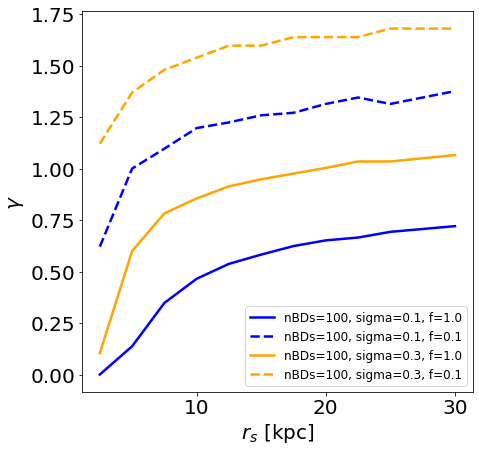

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

plot_UL(ax, "fixedT10v100", 100, 0.1, 1., "blue")
plot_UL(ax, "fixedT10v100", 100, 0.1, 0.1, "blue", "--")
plot_UL(ax, "fixedT10v100", 100, 0.3, 1., "orange")
plot_UL(ax, "fixedT10v100", 100, 0.3, 0.1, "orange", "--")

ax.legend(fontsize=12)
ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")

Text(0.5, 0, '$r_s$ [kpc]')

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


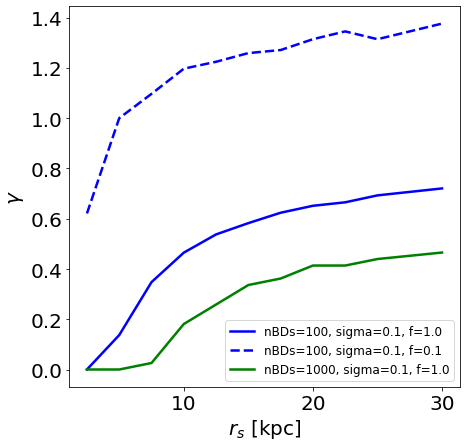

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

plot_UL(ax, "fixedT10v100", 100, 0.1, 1., "blue")
plot_UL(ax, "fixedT10v100", 100, 0.1, 0.1, "blue", "--")
plot_UL(ax, "fixedT10v100", 1000, 0.1, 1., "green")

ax.legend(fontsize=12)
ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")

### Investigate Tcut results

In [77]:
from experimental_sensitivity_CL_Asimov_Tcut import sigma_Tmodel2
from scipy.stats import percentileofscore

conv_Msun_to_kg = 1.98841e+30

def lnL_sb(gamma, f, rs, robs, sigma_robs, Mobs, sigma_Mobs, Aobs, sigma_Aobs,  
           Tobs, sigma_Tobs, Tint, dervTint_M, dervTint_A,                      
           v=None, R=R_jup.value, Rsun=8.178, rho0=0.42, epsilon=1.):           
    """                                                                         
    Return ln(L) assuming predicted temperature = DM + intrinsic                
    """                                                                         
    # Calculate predicted temperature (DM + intrinsic)                          
    Tmodel = temperature_withDM(robs, Tint, M=Mobs*conv_Msun_to_kg, f=f,        
                           p=[gamma, rs, rho0], v=v)                            
                                                                                
    _sigma_Tmodel2 = sigma_Tmodel2(robs, Mobs, Aobs, sigma_robs, sigma_Mobs,    
                                   sigma_Aobs, Tint, dervTint_M, dervTint_A,    
                                   f, [gamma, rs, rho0], v=v, R=R, Rsun=Rsun,   
                                   epsilon=epsilon)                             
    # return                                                                    
    return -0.5*np.sum((Tmodel-Tobs)**2/(sigma_Tobs**2 + _sigma_Tmodel2))       
                                                                                
                                                                                
def lnL_b(sigma_Mobs, sigma_Aobs, Tobs, sigma_Tobs, Tint, dervTint_M,           
          dervTint_A):                                                          
    """                                                                         
    Return ln(L) assuming predicted temperature = intrinsic                     
    """                                                                         
                                                                                
    sigma_Tint2 = (np.power(dervTint_A*sigma_Aobs, 2) +                         
                   np.power(dervTint_M*sigma_Mobs, 2))                          
                                                                                
    # return                                                                    
    return -0.5*np.sum((Tint-Tobs)**2/(sigma_Tobs**2 + sigma_Tint2))  


def TS(gamma, f, rs, robs, sigma_robs, Mobs, sigma_Mobs, Aobs, sigma_Aobs,      
       Tobs, sigma_Tobs, Tint, dervTint_M, dervTint_A,                          
       v=None, R=R_jup.value, Rsun=8.178, rho0=0.42, epsilon=1.):               
    """                                                                         
    Test statistics                                                             
    """                                                                         
    # return                                                                    
    return (-2.*lnL_sb(gamma, f, rs, robs, sigma_robs, Mobs, sigma_Mobs,        
                       Aobs, sigma_Aobs, Tobs, sigma_Tobs, Tint, dervTint_M,    
                       dervTint_A, v=v, R=R, Rsun=Rsun, rho0=rho0,              
                       epsilon=epsilon)                                         
            +2*lnL_b(sigma_Mobs, sigma_Aobs, Tobs, sigma_Tobs, Tint,            
                     dervTint_M, dervTint_A)                                    
            )


def p_value_sb(gamma_k, f, rs, nBDs, relT, relM, relR, relA, points, values,    
               TS_obs, steps=300, Tmin=0., v=None, ex="fixedT10v100Tcut650"):                             
    """                                                                         
    Return p-value for gamma_k @ (f, rs) under s+b hypothesis                   
    """                                                                         
    # Compute TS pdf                                                            
    TS_k = np.zeros(steps)                                                      
    for i in range(steps):                                                      
        # Generate experiments under s+b hypothesis                             
        np.random.seed(i)                                                       
        (robs, sigmarobs, Tobs, sigmaTobs, Mobs, sigmaMobs, Aobs,               
        sigmaAobs) = mock_population_all(nBDs, relT, relM, relR, relA,          
                                           f, gamma_k, rs, Tmin=Tmin,v=v)       
        # Predicted intrinsic temperatures                                         
        xi       = np.transpose(np.asarray([Aobs, Mobs]))                       
        Teff     = griddata(points, values, xi)                                 
        # Load derivatives Tint wrt Age and Mass                                
        data = np.genfromtxt(path + "derivativeTint_" + ex + "_N%i_sigma%.1f_v%i.dat"
                     %(nBDs, relM, i), unpack=True)                           
        dervTint_A = data[0]                                                    
        dervTint_M = data[1]                         
        # TS                                                                    
        TS_k[i] = TS(gamma_k, f, rs, robs, sigmarobs, Mobs, sigmaMobs, Aobs,    
                     sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A,  
                     v=v)                                                                                                 
    # return                                                                    
    return (100-percentileofscore(TS_k, TS_obs, kind="strict"), TS_k)


def p_value_b(gamma_k, f, rs, nBDs, relT, relM, relR, relA, points, values,     
              TS_obs, steps=300, Tmin=0., v=None, ex="fixedT10v100Tcut650"):    
    """                                                                         
    Return p-value for gamma_k @ (f, rs) under b hypothesis                     
    """                                                                         
    # Compute TS pdf                                                            
    TS_k = np.zeros(steps)                                                      
    path = "/home/mariacst/exoplanets/exoplanets/python/data_der/"              
    for i in range(steps):                                                      
        # Generate experiments under s+b hypothesis                             
        np.random.seed(i)                                                     
        (robs, sigmarobs, Tobs, sigmaTobs, Mobs, sigmaMobs, Aobs,               
        sigmaAobs) = mock_population_all(nBDs, relT, relM, relR, relA,          
                                           0., 1., 1., Tmin=Tmin)               
                                                                                
        # Predicted intrinsic temperatures                                      
        xi       = np.transpose(np.asarray([Aobs, Mobs]))                       
        Teff     = griddata(points, values, xi)                                 
        # Load derivatives Tint wrt Age and Mass                                
        data = np.genfromtxt(path + "derivativeTint_" + ex + "_N%i_sigma%.1f_v%i.dat"
                     %(nBDs, relM, i), unpack=True)                           
        dervTint_A = data[0]                                                    
        dervTint_M = data[1]                                                    
        # TS                                                                    
        TS_k[i] = TS(gamma_k, f, rs, robs, sigmarobs, Mobs, sigmaMobs, Aobs,    
                     sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A, v=v)                                               
    # return                                                                    
    return (100-percentileofscore(TS_k, TS_obs, kind="strict"), TS_k)

In [94]:
f         = 0.1                                                 
nBDs      = 100                                                                
sigma     = 0.3                                                                
                                              
steps     = 200 # Need to vary                                                 
                                                                               
relT = 0.1;                                                                    
ex   = "fixedT10v100Tcut650"                                                   
v    = 100. # km/s                                                             
Tcut = 650. # KI                                                               
# Load ATMO2020 model                                                          
path     = "/home/mariacst/exoplanets/exoplanets/data/"                          
data     = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)         
points   = np.transpose(data[0:2, :])                                            
values   = data[2]                                                             
                                                
path = "/home/mariacst/exoplanets/exoplanets/python/data_der/"                 
#path = "/home/mariacst/exoplanets/running/v100_N1e5/data_der/"                
# Generate real observation                                                    
seed      = 250                                                                
np.random.seed(seed)                                                           
(robs, sigmarobs, Tobs, sigmaTobs, Mobs,                                      
    sigmaMobs, Aobs, sigmaAobs) = mock_population_all_Asimov(nBDs, relT,              
                                  sigma, sigma, sigma, 0., 1., 1.,             
                                  Tmin=Tcut, v=v) 

xi   = np.transpose(np.asarray([Aobs, Mobs]))                               
Teff = griddata(points, values, xi)                                         

In [96]:
import imp
import derivatives
imp.reload(derivatives)
from derivatives import derivativeTint_wrt_A, derivativeTint_wrt_M
# Calculate derivatives Tint wrt Age and Mass                               
dervTint_A = np.ones(nBDs)                                                  
dervTint_M = np.ones(nBDs)                                                  
size       = 7000                                                           
h          = 0.001                                                          
from derivatives import derivativeTint_wrt_A, derivativeTint_wrt_M 
for i in range(nBDs):                                                       
    dervTint_A[i] = derivativeTint_wrt_A(Mobs[i], Aobs[i], points, values,  
                                     size=size, h=h)                        
    dervTint_M[i] = derivativeTint_wrt_M(Mobs[i], Aobs[i], points, values,  
                                     size=size, h=h)  

In [97]:
import imp
import derivatives
imp.reload(derivatives)
from derivatives import derivativeTint_wrt_A, derivativeTint_wrt_M
# Calculate derivatives Tint wrt Age and Mass                                                                               
dervTint_M_9000 = np.ones(nBDs)                                                  
size       = 9000                                                           
h          = 0.001                                                          
from derivatives import derivativeTint_wrt_A, derivativeTint_wrt_M 
for i in range(nBDs):                                                                             
    dervTint_M_9000[i] = derivativeTint_wrt_M(Mobs[i], Aobs[i], points, values,  
                                     size=size, h=h)  

In [85]:
gamma_k = 1.79286; rs_k=15.

TS_obs = TS(gamma_k, f, rs_k, robs, sigmarobs, Mobs, sigmaMobs, Aobs,           
                    sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M,               
                    dervTint_A, v=v)

print (TS_obs)

-2.5255541473868988


In [82]:
gamma_k = 1.79286; rs_k=15.

TS_obs = TS(gamma_k, f, rs_k, robs, sigmarobs, Mobs, sigmaMobs, Aobs,           
                    sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M,               
                    dervTint_A, v=v)

print (TS_obs)

-0.32759851604092205


In [51]:
_, TS_bck = p_value_b(gamma_k, f, rs_k, nBDs, relT, sigma, sigma, sigma,                
                      points, values, TS_obs, steps=steps, Tmin=Tcut, v=v)

In [57]:
path    = "../python/"
TS_k_sb = np.genfromtxt(path + "TS_sb_fixedT10v100Tcut650_nBDs100_f0.1_steps200_sigma0.3_gamma%.5frs%.1f.dat"%(gamma_k, rs_k), unpack="True")

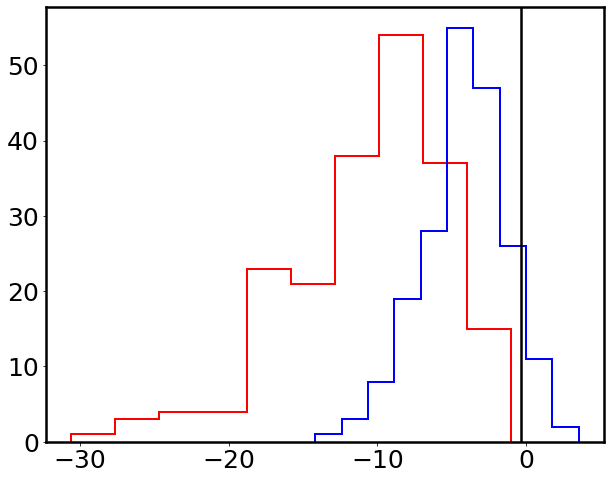

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.hist(TS_k_sb, color="r", histtype="step", lw=2.);
ax.hist(TS_bck, color="b", histtype="step", lw=2.);
ax.axvline(TS_obs, color="k", lw=2.5, ls="-")

In [68]:
from mock_generation import mock_population_all_Asimov

f         = 0.1                                                 
nBDs      = 100                                                                
sigma     = 0.3                                                                
                                              
steps     = 200 # Need to vary                                                 
                                                                               
relT = 0.1;                                                                    
ex   = "fixedT10v100"                                                   
v    = 100. # km/s                                                             
Tcut = 650. # KI                                                               
# Load ATMO2020 model                                                          
path     = "/home/mariacst/exoplanets/exoplanets/data/"                          
data     = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)         
points   = np.transpose(data[0:2, :])                                            
values   = data[2]                                                             
                                                
path = "/home/mariacst/exoplanets/exoplanets/python/data_der/"                 
#path = "/home/mariacst/exoplanets/running/v100_N1e5/data_der/"                
# Generate real observation                                                    
seed      = 250                                                                
np.random.seed(seed)                                                           
(robs, sigmarobs, Tobs, sigmaTobs, Mobs,                                      
    sigmaMobs, Aobs, sigmaAobs) = mock_population_all_Asimov(nBDs, relT,              
                                  sigma, sigma, sigma, 0., 1., 1.,             
                                  Tmin=Tcut, v=v) 

xi   = np.transpose(np.asarray([Aobs, Mobs]))                               
Teff = griddata(points, values, xi)                                         
# Load derivatives Tint wrt Age and Mass                                    
data = np.genfromtxt(path + "derivativeTint_" + ex + "_N%i_sigma%.1f_v%i.dat"
                 %(nBDs, sigma, seed), unpack=True)                         
dervTint_A = data[0]                                                        
dervTint_M = data[1] 

In [69]:
gamma_k = 1.5552

TS_obs = TS(gamma_k, f, rs_k, robs, sigmarobs, Mobs, sigmaMobs, Aobs,           
                    sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M,               
                    dervTint_A, v=v)

print(TS_obs)

0.587254134518223


In [74]:
gamma_k = 1.79286; rs_k=15.

TS_obs = TS(gamma_k, f, rs_k, robs, sigmarobs, Mobs, sigmaMobs, Aobs,           
                    sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M,               
                    dervTint_A, v=v) 

_, TS_bck = p_value_b(gamma_k, f, rs_k, nBDs, relT, sigma, sigma, sigma,                
                      points, values, TS_obs, steps=steps, Tmin=0., v=v, ex="fixedT10v100")

In [79]:
_, TS_k_s = p_value_sb(gamma_k, f, rs_k, nBDs, relT, sigma, sigma, sigma, points, values,    
                       TS_obs, steps=steps, Tmin=0., v=v, ex="fixedT10v100")

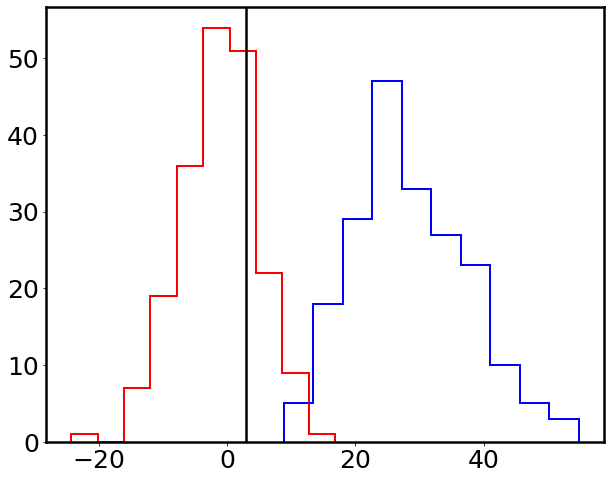

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.hist(TS_k_s, color="r", histtype="step", lw=2.);
ax.hist(TS_bck, color="b", histtype="step", lw=2.);
ax.axvline(TS_obs, color="k", lw=2.5, ls="-")

In [79]:
from mock_generation import mock_population_all_Asimov

nBDs = 100
relT = 0.1
sigma = 0.1                                                                
ex   = "fixedT10v100Tcut650"                                                
v    = 100. # km/s                                                          
Tcut = 650. # KI                                                            
# Load ATMO2020 model                                                          
path     = "/home/mariacst/exoplanets/exoplanets/data/"                     
data     = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)    
points   = np.transpose(data[0:2, :])                                       
values   = data[2]                                                                                                     
path = "/home/mariacst/exoplanets/exoplanets/python/data_der/"              
#path = "/home/mariacst/exoplanets/running/v100_N1e5/data_der/"             
# Generate real observation                                                 
seed      = 115                                                             
np.random.seed(seed)                                                        
(robs, sigmarobs, Tobs, sigmaTobs, Mobs,                                    
    sigmaMobs, Aobs, sigmaAobs) = mock_population_all(nBDs, relT,    
                                  sigma, sigma, sigma, 0., 1., 1.,          
                                  Tmin=Tcut, v=v)                           
xi   = np.transpose(np.asarray([Aobs, Mobs]))                               
Teff = griddata(points, values, xi)                                         
# Load derivatives Tint wrt Age and Mass                                    
data = np.genfromtxt(path + "derivativeTint_" + ex + "_N%i_sigma%.1f_v%i.dat"
                 %(nBDs, sigma, seed), unpack=True)                         
dervTint_A = data[0]                                                        
dervTint_M = data[1] 

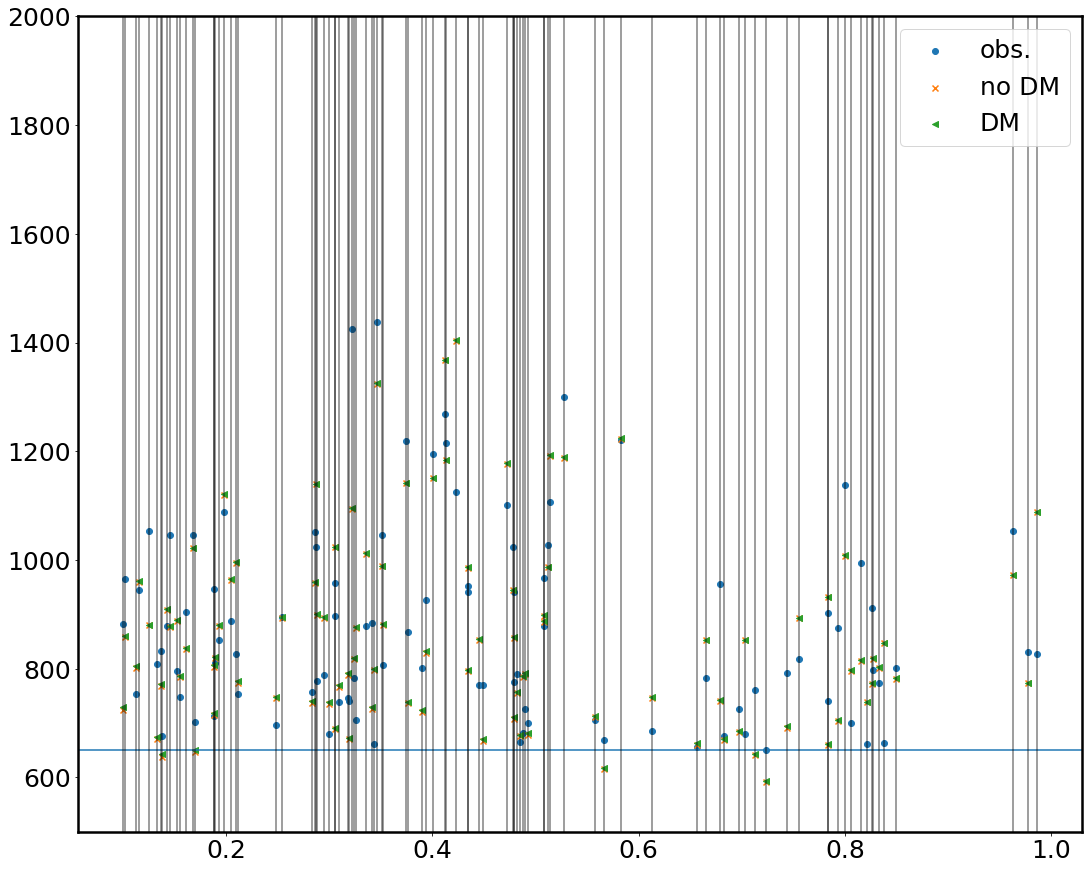

In [88]:
fig, ax = plt.subplots(1, 1, figsize=(18, 15))
ax.scatter(robs, Tobs, label="obs.")
ax.scatter(robs, Teff, label="no DM", marker="x")

Tmodel = temperature_withDM(robs, Teff, M=Mobs*conv_Msun_to_kg, f=1.,        
                           p=[gamma_k, rs_k, 0.42], v=100.) 
ax.scatter(robs, Tmodel, label="DM", marker="<")
ax.set_ylim(500, 2000)
ax.axhline(650.)
ax.legend()

for r in robs:
    ax.axvline(r, ls="-", color="k", alpha=0.5)

In [78]:
gamma_k = 0.4; rs_k = 30.

TS_k_obs = TS(gamma_k, 1., rs_k, robs, sigmarobs, Mobs, sigmaMobs, Aobs,           
              sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M,               
              dervTint_A, v=100.) 

print(TS_k_obs)

-0.5293022616940988


In [31]:
#path    = "../python/data_UL/checkTcut/"
path = "../python/"
TS_k_b  = np.genfromtxt(path + "TS_b_fixedT10v100Tcut650_nBDs100_f1.0_steps200_sigma0.1_gamma%.5frs%.1f.dat"%(gamma_k, rs_k), unpack="True")
TS_k_sb = np.genfromtxt(path + "TS_sb_fixedT10v100Tcut650_nBDs100_f1.0_steps200_sigma0.10000_gamma%.4frs%.1f.dat"%(gamma_k, rs_k), unpack="True")

from scipy.stats import percentileofscore 
p_b  = 100-percentileofscore(TS_k_b, TS_k_obs, kind="strict")
p_sb = 100-percentileofscore(TS_k_sb, TS_k_obs, kind="strict")
print(p_b, p_sb)

CL = p_sb/p_b
print(CL, CL < 0.05)

1.5 0.0
0.0 True


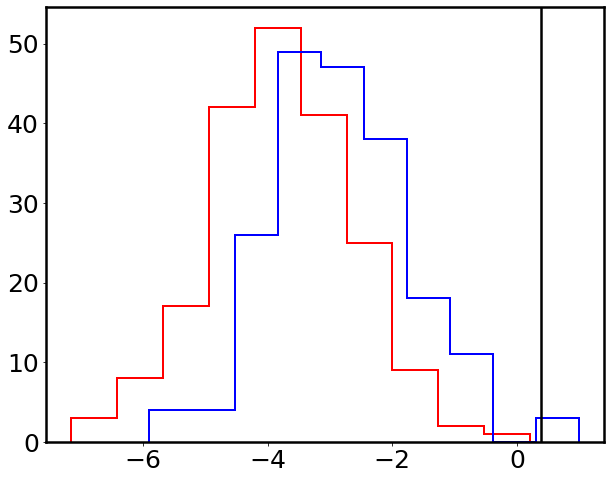

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.hist(TS_k_sb, color="r", histtype="step", lw=2.);
ax.hist(TS_k_b, color="b", histtype="step", lw=2.);
ax.axvline(TS_k_obs, color="k", lw=2.5, ls="-")

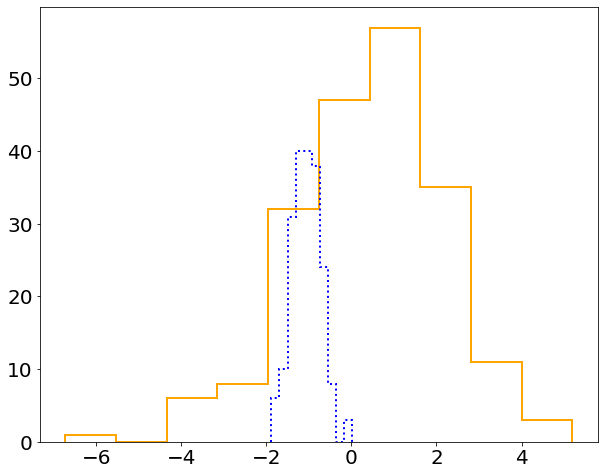

In [13]:
path    = "../python/"
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

from scipy.stats import percentileofscore

gamma_k=0.4; rs_k=30.
TS_k_sb  = np.genfromtxt(path + "TS_sb_fixedT10v100Tcut650_nBDs100_f1.0_steps400_sigma0.1_gamma%.1frs%.1f_screen.dat"%(gamma_k, rs_k), unpack="True")
ax.hist(TS_k_sb[0:200], color="orange", histtype="step", lw=2.);
#print(100-percentileofscore(TS_k_b, TS_k_obs, kind="strict"))

TS_k_sb  = np.genfromtxt(path + "TS_sb_fixedT10v100Tcut650_nBDs100_f1.0_steps200_sigma0.1_gamma%.1frs%.1f_screen.dat"%(gamma_k, rs_k), unpack="True")
ax.hist(TS_k_sb, color="b", histtype="step", lw=2., ls=":");
#ax.axvline(TS_k_obs, color="k", lw=2.5, ls="-")
#print(100-percentileofscore(TS_k_b, TS_k_obs, kind="strict"))

# POWER LAW

Difference between power law and gNFW

In [2]:
import sys
sys.path.append("../python/")
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from utils import gNFW_rho

In [4]:
Rsun = 8.122
r    = np.logspace(-1, 0, 20)
rho  = gNFW_rho(Rsun, r, [1.3, 20., 0.42])

def cte_PL(Rsun, params):
    gamma = params[0]; rs = params[1]; rho0 = params[2];
    return rho0*np.power(Rsun, gamma)*np.power(1+Rsun/rs, 3.-gamma)

def PL_rho(Rsun, r, params):
    gamma = params[0]
    A_cte = cte_PL(Rsun, params)
    return A_cte*np.power(r, -gamma)

rho_PL = PL_rho(Rsun, r, [1.3, 20., 0.42])

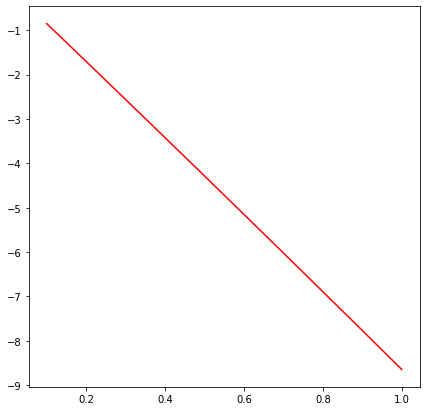

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.plot(r, (rho-rho_PL)/rho*100, color="red")
#ax.set_yscale("log"); ax.set_xscale("log")

In [55]:
import os, glob
path = "/home/mariacst/exoplanets/exoplanets/python/gNFW/TSlogL/logs/"
UL   = []

i=0; rs=20
for filename in glob.glob(os.path.join(path, "outputTS_gNFW_T650_%i_*.log")%rs):
    data = np.genfromtxt(os.path.join(os.getcwd(), filename))
    try:
        UL.append(data[1])
    except:
        i+=1
        print(i, "not finished!")
np.savetxt("../python/data_UL/UL_TSlogL_T650_nBDs1000_sigma0.1_f1.0_steps200_rs%.1f_gNFW.dat"%float(rs), 
           np.array(UL), "%.4f")        

In [56]:
print(len(UL), np.min(UL), np.max(UL))

200 1.3182 1.4697


In [18]:
path = "/home/mariacst/exoplanets/exoplanets/python/data_UL/"
UL = np.genfromtxt(path + "UL_baseline_nBDs1000_sigma0.1_f1.0_steps200_rs20.0_gNFW.dat", unpack=True)

1.1061 200


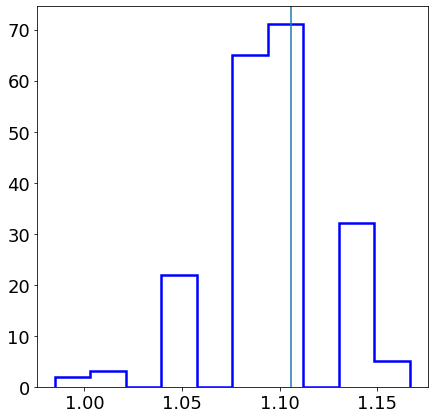

In [50]:
#UL_Asimov =  0.6666

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.hist(UL, lw=2.5, color="blue", histtype="step", bins=10);
#ax.axvline(UL_Asimov, lw=2.5, color="k")
ax.axvline(np.median(UL))
print(np.median(UL), len(UL))
#print(np.min(UL), np.max(UL))

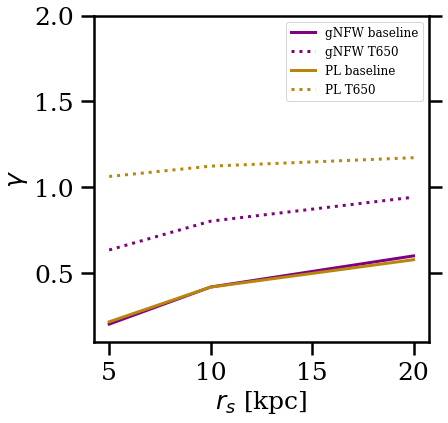

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

plt.rcParams['axes.linewidth'] = 2.5
plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=25)

ax.tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)

path="../python/data_UL/"

line_col = 'purple'
col = 'rebeccapurple'

smooth=0.8

ex="baseline"; nBDs=100; f=1.; sigma=0.1
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_steps200_Asimov_gNFW.dat" 
                         %(nBDs, sigma, f), unpack=True)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3., label="gNFW baseline")

ex="T650";
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_steps200_Asimov_gNFW.dat" 
                         %(nBDs, sigma, f), unpack=True)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, ls=":", lw=3., label="gNFW T650")


col = 'goldenrod'
line_col = 'darkgoldenrod'
ex="baseline"
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_steps200_Asimov_PL.dat" 
                       %(nBDs, sigma, f), unpack=True)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, lw=3., label="PL baseline")

ex="T650"
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_steps200_Asimov_PL.dat" 
                       %(nBDs, sigma, f), unpack=True)
ax.plot(data[0], gaussian_filter1d(data[1], sigma=smooth), color=line_col, ls=":", lw=3., label="PL T650")

ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")
#ax.set_xlim(2., 30.); 
ax.set_ylim(0.1, 2.); ax.legend(fontsize=12)

# Notice that for TSlogL, I am not gaining much by going from N=100 --> N=1000
Why??? Does this result make sense???

Text(0.5, 0, '$r_s$ [kpc]')

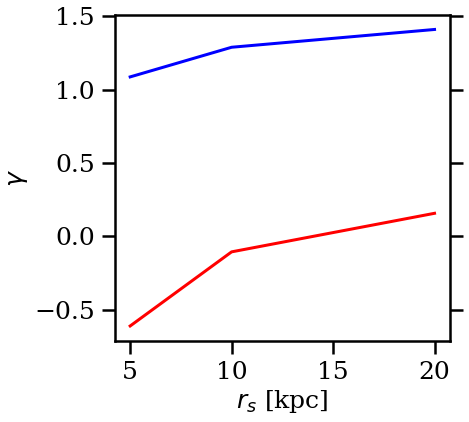

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

plt.rcParams['axes.linewidth'] = 2.5
plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=25)

ax.tick_params(which='major',direction="out",width=2.5,length=13,right=True,top=False,pad=7)

path1="/home/mariacst/exoplanets/results/upper_limit/fancy/"
path2="/home/mariacst/exoplanets/results/upper_limit/"

line_col1 = 'purple'
line_col2 = 'darkgoldenrod'

nBDs=100; sigma=0.1; f=1.
rs = [5., 10., 20.]; 
UL1 = []; UL2 = []

for _rs in rs:
    ex="baseline_NL";
    data = np.genfromtxt(path2 + "UL_TSlogL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_rs%.1f_gNFW.dat"
                         %(1000, sigma, f, _rs), unpack=True)
    UL1.append(np.median(data[1]))
    ex="T650_NL";
    data = np.genfromtxt(path2 + "UL_TSlogL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_rs%.1f_gNFW.dat"
                       %(1000, sigma, f, _rs), unpack=True)
    UL2.append(np.median(data[1]))
    
ax.plot(rs, UL1, color="red", ls="-", lw=3.)
ax.plot(rs, UL2, color="blue", ls="-", lw=3.)
    
ax.set_ylabel(r"$\gamma$"); ax.set_xlabel("$r_s$ [kpc]")
#ax.set_xlim(2., 30.); 
#ax.set_ylim(-0.3, 2.); ax.legend(fontsize=12)

# Sensitivity - opposite to UL

In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/python/gNFW/TSlogL/detect_signal/non_linear")

In [6]:
from mock_generation import mock_population_all
from experimental_sensitivity_CL_gNFW_slurm import _TS_obs
from scipy.interpolate import griddata, interp1d
import numpy as np

In [30]:
def UL_at_rs(rs, f, nBDs, relT, relM, relR, relA, points, values,                  
             a, b, b1, c, c1,                                                      
             rho0=0.42, Tmin=0., v=None, gamma_min=0.01, gamma_max=2):          
    # Grid in gamma                                                                
    gamma_k = np.linspace(gamma_min, gamma_max, 20) # change this?                
    #print(gamma_k)                                                                
    for g in gamma_k:                                                              
        (robs, sigmarobs, Tobs, sigmaTobs, Mobs,                                   
        sigmaMobs, Aobs, sigmaAobs) = mock_population_all(nBDs, relT,              
                                      relM, relR, relA, f, g, rs,               
                                      Tmin=Tmin, v=v)                              
        xi   = np.transpose(np.asarray([Aobs, Mobs]))                              
        Teff = griddata(points, values, xi)                                        
        # Observed TS                                                              
        TS_obs = _TS_obs(g, f, rs, robs, sigmarobs, Mobs, sigmaMobs, Aobs,         
                         sigmaAobs, Tobs, sigmaTobs, Teff, a, b, b1, c, c1,     
                         v=v)                                                      
        print(g, TS_obs)                                                                 
    return

In [26]:
# Load ATMO2020 model                                                       
path     = "/home/mariacst/exoplanets/running/data/"                        
data     = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)    
points   = np.transpose(data[0:2, :])                                       
values   = data[2]                                                          
# Generate real observation                                                 
#seed     = int(sys.argv[2]) + 350                                          
#np.random.seed(seed)                                                       
                                                                            
# Calculate derivatives Tint wrt Age and Mass                               
masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)      
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)           
a_interp = interp1d(masses, a)                                              
b_interp = interp1d(masses, b)                                              
c_interp = interp1d(ages, c)                                                
masses, b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)      
b1_interp  = interp1d(masses, b1)                                           
ages, c1  = np.genfromtxt(path + "dderv_ana_wrt_MA.dat", unpack=True)       
c1_interp = interp1d(ages, c1) 

In [39]:
UL_at_rs(20., 1., 100, 0.1, 0.1, 0.1, 0.1, points, values, a_interp, b_interp, b1_interp, c_interp,
         c1_interp)

0.01 0.5376577606004957
0.11473684210526315 1.34417570144808
0.21947368421052632 -0.3964144362928437
0.3242105263157895 -0.3237519340682411
0.42894736842105263 -7.03764275705214
0.5336842105263158 2.1567709644062916
0.638421052631579 10.545188471680149
0.7431578947368421 9.246024418859633
0.8478947368421053 21.12802926495067
0.9526315789473684 21.79383072900066
1.0573684210526315 35.11221872669785
1.1621052631578948 73.74974596339723
1.266842105263158 48.61953237441048
1.371578947368421 153.76921326750414
1.4763157894736842 187.63962111909177
1.5810526315789473 191.442319146964
1.6857894736842105 242.31993329703596
1.7905263157894737 395.31257731807625
1.8952631578947368 461.66151669100884
2.0 579.7474872378477


# Back to plotting

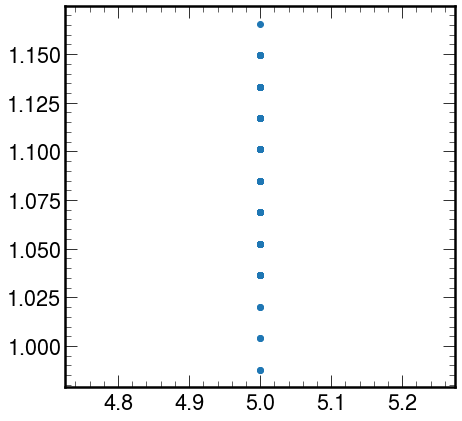

In [7]:
_rs=5.; nBDs=1000; sigma=0.1; f=1.
#path="/home/mariacst/exoplanets/exoplanets/python/gNFW/TSlogL/non_linear/T650/"
path="/home/mariacst/exoplanets/results/upper_limit/"
ex="T650"
data = np.genfromtxt(path + "UL_TSlogL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_rs%.1f_gNFW.dat"
                         %(nBDs, sigma, f, _rs), unpack=True)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.scatter(data[0], data[1])

-0.3636
-0.6868
-0.3637
-0.728916


Text(1, 0, '$\\gamma$')

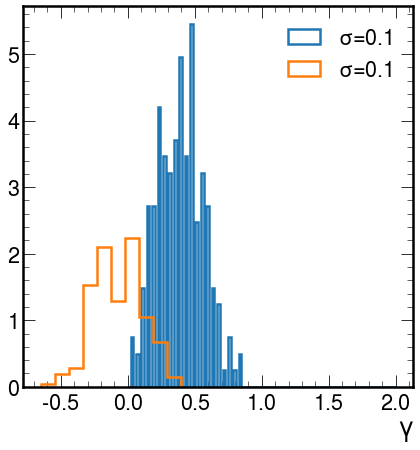

In [69]:
_rs=10.; nBDs=100; sigma=0.1; f=1.
path="/home/mariacst/exoplanets/results/upper_limit/"
ex="baseline"
data = np.genfromtxt(path + "UL_TSlogL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_rs%.1f_gNFW.dat"
                         %(nBDs, sigma, f, _rs), unpack=True)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.hist(data[1], density=True, histtype="step", lw=2.5, label=r"$\sigma$=%.1f"%sigma, bins=np.linspace(0, 2, 100));
print(np.percentile(data[1], 16)-np.percentile(data[1], 84))
print(np.mean(np.percentile(data[1], 2)-np.percentile(data[1], 98)))

sigma=0.1; nBDs=1000
data = np.genfromtxt(path + "UL_TSlogL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_rs%.1f_gNFW.dat"
                         %(nBDs, sigma, f, _rs), unpack=True)

ax.hist(data[1], density=True, histtype="step", lw=2.5, label=r"$\sigma$=%.1f"%sigma);
print(np.percentile(data[1], 16)-np.percentile(data[1], 84))
print(np.mean(np.percentile(data[1], 2)-np.percentile(data[1], 98)))
ax.legend()
ax.set_xlabel(r"$\gamma$")

-0.32319999999999993
-0.621704
-0.33449599999999996
-0.6177859999999996


Text(1, 0, '$\\gamma$')

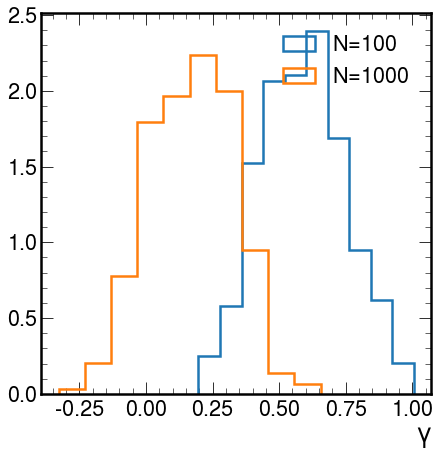

In [71]:
_rs=20.; nBDs=100; sigma=0.1; f=1.
path="/home/mariacst/exoplanets/exoplanets/python/gNFW/TSlogL/"
#path="/home/mariacst/exoplanets/results/upper_limit/"
ex="baseline"
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_sigma%.1f_rs%.1f_gNFW.dat"
                         %(nBDs, f, sigma, _rs), unpack=True)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.hist(data[1], density=True, histtype="step", lw=2.5, label=r"$N$=100");
print(np.percentile(data[1], 16)-np.percentile(data[1], 84))
print(np.percentile(data[1], 2)-np.percentile(data[1], 98))
nBDs=1000; sigma=0.1;
data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_f%.1f_sigma%.1f_rs%.1f_gNFW.dat"
                         %(nBDs, f, sigma, _rs), unpack=True)

ax.hist(data[1], density=True, histtype="step", lw=2.5, label=r"$N$=1000");
print(np.percentile(data[1], 16)-np.percentile(data[1], 84))
print(np.mean(np.percentile(data[1], 2)-np.percentile(data[1], 98)))
ax.legend()
ax.set_xlabel(r"$\gamma$")
#fig.savefig("gammaUL_distribution_baseline_nBDs100.png", box_inche="tight")

206.23015874987337
231.93341586867564


<ErrorbarContainer object of 3 artists>

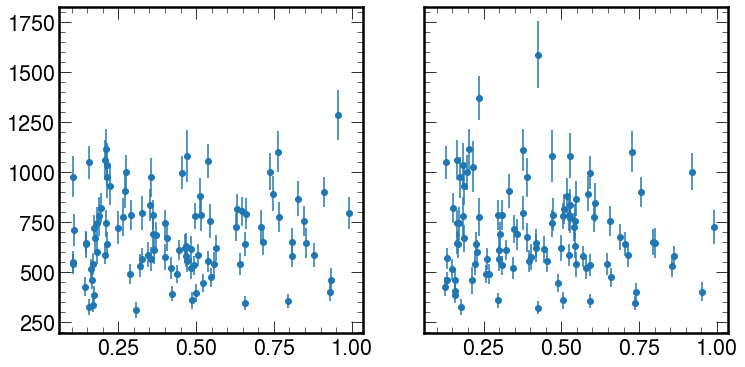

In [7]:
import mock_generation_test, imp
imp.reload(mock_generation_test)
from mock_generation_test import mock_population_all

seed=84

fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
sigma=0.1
np.random.seed(seed)
(robs, sigmarobs, r, Tobs, sigmaTobs, T, Mobs,                                  
    sigmaMobs, M, Aobs, sigmaAobs, A) = mock_population_all(100, 0.1, sigma, sigma, sigma, 0., 1., 1., 
                                                            Tmin=0., v=100.)
print(np.std(Tobs))
ax[0].errorbar(robs, Tobs, yerr=sigmaTobs, fmt="o")

sigma=0.3
np.random.seed(seed)
(robs, sigmarobs, r, Tobs, sigmaTobs, T, Mobs,                                  
    sigmaMobs, M, Aobs, sigmaAobs, A) = mock_population_all(100, 0.1, sigma, sigma, sigma, 0., 1., 1., 
                                                            Tmin=0., v=100.)
print(np.std(Tobs))

ax[1].errorbar(robs, Tobs, yerr=sigmaTobs, fmt="o")

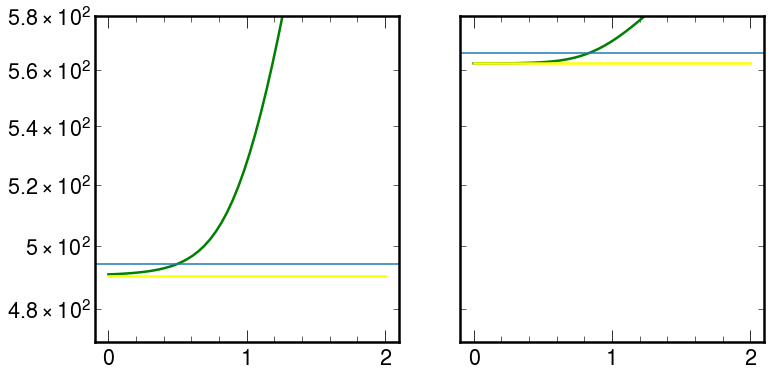

In [26]:
sys.path.append("/home/mariacst/exoplanets/exoplanets/python/gNFW/TSlogL")
from experimental_sensitivity_CL_gNFW_slurm import lnL_sb_obs, lnL_b_obs
from scipy.interpolate import interp1d, griddata
from derivatives import derivativeTintana_wrt_A
gamma = np.linspace(0, 2, 50)

# Load ATMO2020 model                                                       
path     = "/home/mariacst/exoplanets/running/data/"                        
data     = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)    
points   = np.transpose(data[0:2, :])                                       
values   = data[2] 

sigma=0.1
np.random.seed(seed)
(robs, sigmarobs, r, Tobs, sigmaTobs, T, Mobs,                                  
    sigmaMobs, M, Aobs, sigmaAobs, A) = mock_population_all(100, 0.1, sigma, sigma, sigma, 0., 1., 1., 
                                                            Tmin=0., v=100.)
xi   = np.transpose(np.asarray([Aobs, Mobs]))                              
Teff = griddata(points, values, xi)                                        
# Calculate derivatives Tint wrt Age and Mass                              
masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)  
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)          
a_interp = interp1d(masses, a)                                             
b_interp = interp1d(masses, b)                                             
c_interp = interp1d(ages, c)                                               
                                                                           
dervTint_A = derivativeTintana_wrt_A(Mobs, Aobs, a_interp, b_interp)                                                 
dervTint_M = c_interp(Aobs)                                                


ln_sb = np.ones(len(gamma))*1000; ln_b = np.ones(len(gamma))*1000

for i in range(len(gamma)):
    ln_sb[i] = lnL_sb_obs(gamma[i], 1., 20., robs, sigmarobs, Mobs, sigmaMobs, Aobs, sigmaAobs, 
                          Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)
    ln_b[i] = lnL_b_obs(sigmaMobs, sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)
    
 
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
ax[0].plot(gamma, -ln_sb, color="green", lw=2.5)
ax[0].plot(gamma, -ln_b, color="yellow", lw=2.5)
ax[0].axhline(-ln_b[0] + 3.84)


sigma=0.3
np.random.seed(seed)
(robs, sigmarobs, r, Tobs, sigmaTobs, T, Mobs,                                  
    sigmaMobs, M, Aobs, sigmaAobs, A) = mock_population_all(100, 0.1, sigma, sigma, sigma, 0., 1., 1., 
                                                            Tmin=0., v=100.)
xi   = np.transpose(np.asarray([Aobs, Mobs]))                              
Teff = griddata(points, values, xi)                                        
# Calculate derivatives Tint wrt Age and Mass                              
masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)  
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)          
a_interp = interp1d(masses, a)                                             
b_interp = interp1d(masses, b)                                             
c_interp = interp1d(ages, c)                                               
                                                                           
dervTint_A = derivativeTintana_wrt_A(Mobs, Aobs, a_interp, b_interp)                                                 
dervTint_M = c_interp(Aobs)   

ln_sb = np.ones(len(gamma))*1000; ln_b = np.ones(len(gamma))*1000

for i in range(len(gamma)):
    ln_sb[i] = lnL_sb_obs(gamma[i], 1., 20., robs, sigmarobs, Mobs, sigmaMobs, Aobs, sigmaAobs, 
                          Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)
    ln_b[i] = lnL_b_obs(sigmaMobs, sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)

ax[1].plot(gamma, -ln_sb, color="green", lw=2.5)
ax[1].plot(gamma, -ln_b, color="yellow", lw=2.5)
ax[1].axhline(-ln_b[0] + 3.84)
ax[1].set_ylim(470, 580)

ax[0].set_yscale("log")

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:77: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "box_inche" which is no longer supported as of 3.3 and will become an error two minor releases later


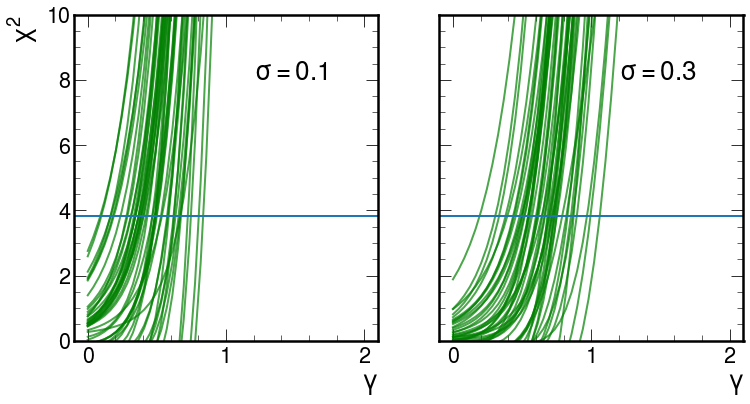

In [44]:
sys.path.append("/home/mariacst/exoplanets/exoplanets/python/gNFW/TSlogL")
from experimental_sensitivity_CL_gNFW_slurm import lnL_sb_obs, lnL_b_obs
from scipy.interpolate import interp1d, griddata
from derivatives import derivativeTintana_wrt_A
gamma = np.linspace(0, 2, 50)

# Load ATMO2020 model                                                       
path     = "/home/mariacst/exoplanets/running/data/"                        
data     = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)    
points   = np.transpose(data[0:2, :])                                       
values   = data[2] 

fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for seed in range(50):
    sigma=0.1
    np.random.seed(seed)
    (robs, sigmarobs, r, Tobs, sigmaTobs, T, Mobs,                                  
        sigmaMobs, M, Aobs, sigmaAobs, A) = mock_population_all(100, 0.1, sigma, sigma, sigma, 0., 1., 1., 
                                                                Tmin=0., v=100.)
    xi   = np.transpose(np.asarray([Aobs, Mobs]))                              
    Teff = griddata(points, values, xi)                                        
    # Calculate derivatives Tint wrt Age and Mass                              
    masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)  
    ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)          
    a_interp = interp1d(masses, a)                                             
    b_interp = interp1d(masses, b)                                             
    c_interp = interp1d(ages, c)                                               
                                                                               
    dervTint_A = derivativeTintana_wrt_A(Mobs, Aobs, a_interp, b_interp)                                                 
    dervTint_M = c_interp(Aobs)                                                
    
    
    ln_sb = np.ones(len(gamma))*1000; ln_b = np.ones(len(gamma))*1000
    chi2  = np.ones(len(gamma))*1000
    
    for i in range(len(gamma)):
        ln_sb[i] = lnL_sb_obs(gamma[i], 1., 20., robs, sigmarobs, Mobs, sigmaMobs, Aobs, sigmaAobs, 
                              Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)
        ln_b[i] = lnL_b_obs(sigmaMobs, sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)
        chi2[i] = -2*ln_sb[i] + 2*ln_b[i]
        
    ax[0].plot(gamma, chi2, color="green", lw=2., alpha=0.7)
    ax[0].axhline(3.84)
    
    
    sigma=0.3
    np.random.seed(seed)
    (robs, sigmarobs, r, Tobs, sigmaTobs, T, Mobs,                                  
        sigmaMobs, M, Aobs, sigmaAobs, A) = mock_population_all(100, 0.1, sigma, sigma, sigma, 0., 1., 1., 
                                                                Tmin=0., v=100.)
    xi   = np.transpose(np.asarray([Aobs, Mobs]))                              
    Teff = griddata(points, values, xi)                                        
    # Calculate derivatives Tint wrt Age and Mass                              
    masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)  
    ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)          
    a_interp = interp1d(masses, a)                                             
    b_interp = interp1d(masses, b)                                             
    c_interp = interp1d(ages, c)                                               
                                                                               
    dervTint_A = derivativeTintana_wrt_A(Mobs, Aobs, a_interp, b_interp)                                                 
    dervTint_M = c_interp(Aobs)   
    
    ln_sb = np.ones(len(gamma))*1000; ln_b = np.ones(len(gamma))*1000
    
    for i in range(len(gamma)):
        ln_sb[i] = lnL_sb_obs(gamma[i], 1., 20., robs, sigmarobs, Mobs, sigmaMobs, Aobs, sigmaAobs, 
                              Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)
        ln_b[i] = lnL_b_obs(sigmaMobs, sigmaAobs, Tobs, sigmaTobs, Teff, dervTint_M, dervTint_A)
        chi2[i] = -2*ln_sb[i] + 2*ln_b[i]
    
    ax[1].plot(gamma, chi2, color="green", lw=2., alpha=0.7)
    ax[1].axhline(3.84)
ax[0].set_ylim(0, 10)
ax[0].text(1.2, 8, r"$\sigma=0.1$"); ax[1].text(1.2, 8, r"$\sigma=0.3$")
ax[0].set_ylabel(r"$\chi^2$"); ax[0].set_xlabel(r"$\gamma$"); ax[1].set_xlabel(r"$\gamma$")
fig.savefig("chi2_vs_gamma_baseline_nBDs100.png", box_inche="tight")

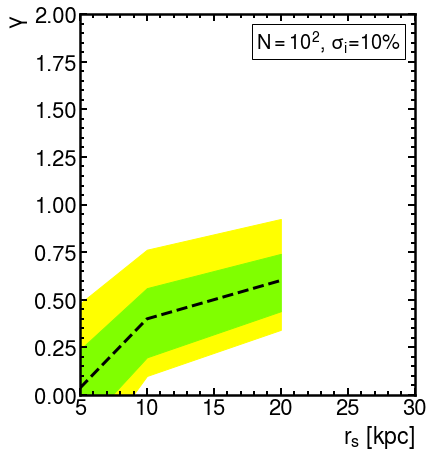

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 7), sharex=True, sharey=True)

path="/home/mariacst/exoplanets/results/upper_limit/"

ex="baseline"; f=1.; sigma=0.1
nBDs=100;
rs = [5., 10., 20.]; UL = []; gamma_UL_2sigma_minus=[]
gamma_UL_2sigma_plus=[]; gamma_UL_1sigma_minus=[]; gamma_UL_1sigma_plus=[]

for _rs in rs:
    data = np.genfromtxt(path + "UL_TSlogL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_rs%.1f_gNFW.dat"
                         %(nBDs, sigma, f, _rs), unpack=True)
    UL.append(np.median(data[1])); 
    gamma_UL_1sigma_minus.append(np.percentile(data[1], 15.85))
    gamma_UL_1sigma_plus.append(np.percentile(data[1], 84.15)); 
    gamma_UL_2sigma_plus.append(np.percentile(data[1], 97.7))
    gamma_UL_2sigma_minus.append(np.percentile(data[1], 2.30))
#ax.fill_between(data[0], gaussian_filter1d(data[1], sigma=smooth), y2=2.,color=col,alpha=0.4,zorder=zo)

ax[0].plot(rs, UL, color="k", lw=3., ls="--")

smooth=0.1
ax[0].fill_between(rs, gaussian_filter1d(gamma_UL_2sigma_minus, sigma=smooth), 
                y2=gaussian_filter1d(gamma_UL_1sigma_minus, sigma=smooth), color="#ffff00")
ax[0].fill_between(rs, gaussian_filter1d(gamma_UL_1sigma_plus, sigma=smooth),
                y2=gamma_UL_2sigma_plus, color="#ffff00")
ax[0].fill_between(rs, gaussian_filter1d(gamma_UL_1sigma_minus, sigma=smooth),
                y2=gaussian_filter1d(gamma_UL_1sigma_plus, sigma=smooth), color="#80ff00")


#ax.text(10, 1.1, "nBDs=%i, f=1, $\sigma=$10"%(nBDs)+"$\%$",color=line_col,fontsize=small_fs,rotation=10)

ax[0].set_ylabel(r"$\gamma$", fontsize=23); ax[0].set_xlabel(r"$r_s$ [kpc]", fontsize=23)
ax[0].set_ylim(0., 2); ax[0].set_xlim(5., 30.)

from matplotlib.offsetbox import AnchoredText
text_box = AnchoredText((r"$N=10^{%i}$, $\sigma_i$=%i"                      
                            %(int(np.log10(nBDs)), int(sigma*100))            
                            + "$\% $"),                                         
                            frameon=True, loc=1, pad=0.2, prop=dict(size=20))   
plt.setp(text_box.patch, facecolor="white")                                 
ax.add_artist(text_box)  

plt.setp(ax.get_xticklabels(), fontsize=22)
plt.setp(ax.get_yticklabels(), fontsize=22)


ax.tick_params(which='major',direction="in",width=2.,length=7,right=True,top=True,pad=3)
ax.tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=True)
fig.savefig("ul_" + ex + "_nBDs%i_sigma%.1f_f%.1f.png"%(nBDs, sigma, f), bbox_inches="tight")
#ax.set_ylim(1., 1.5)

# Checking the code once more

In [5]:
def delta_temperature_Tint(M, A, sigma_A, Tint, a, b):
    """                                                                            
    2nd/3rd-order correction to expected temperature due to non-linear relation 
    between temperature and mass, age, galactocentric distance variables.          
                                                                                   
    Correction = 0.5*Tr(H_0*C)=0.5*(delta_MM T*sigma_M^2 +
                                    delta_AA T*sigma_A^2)
    """
    # return
    return 0.5*(dderivativeT_wrt_A(M, A, Tint, Tint, a, b)*np.power(sigma_A, 2))  

def delta_sigma_Tint2(M, A, sigma_M, sigma_A, Ttot, a, b, b1, c, c1):        
    """                                                                         
    2nd-order correction to linear propagion of uncertainties                   
    """
    MA = (                                                                      
    dderivativeT_wrt_AM(1., M, A, a, b, b1, c, Ttot, 0., Ttot, 1., [1., 1., 1.], None)*sigma_A**2*
    dderivativeT_wrt_MA(1., M, A, a, b, c, c1, Ttot, 0., Ttot, 1., [1., 1., 1.], None)*sigma_M**2
            )
    # return                                                                    
    return (0.5*(np.power(dderivativeT_wrt_A(M, A, Ttot, Ttot, a, b)*sigma_A**2, 2))  
            + MA)


def lnL_b_obs(Mobs, Aobs, sigma_Mobs, sigma_Aobs, Tobs, sigma_Tobs, Tint, 
              a, b, b1, c, c1):
    """
    Return ln(L) assuming predicted temperature = intrinsic
    """  
    Tint_corr = Tint + delta_temperature_Tint(Mobs, Aobs, sigma_Aobs, Tint, a, b) 

    # TODO: check that delta_sigma_Tint2 is doing correct thing!!!!
    sigmaT2_corr = (sigma_Tmodel2(1., Mobs, Aobs, 0., sigma_Mobs, sigma_Aobs,
                            Tint, 0., Tint, 1., [1., 1., 1.], a, b, c, None) + 
                    delta_sigma_Tint2(Mobs, Aobs,
                        sigma_Mobs, sigma_Aobs, Tint, a, b, b1, c, c1)
                    )  
    # return
    return -0.5*np.sum(np.log(sigma_Tobs**2 + sigmaT2_corr) + 
                       (Tint_corr-Tobs)**2/(sigma_Tobs**2 + sigmaT2_corr)) 

In [ ]:
f         = 1.
nBDs      = 100
sigma     = 0.3
gamma_max = 3.5 # 2.5

rs        = float(sys.argv[1])
gamma_min = -1.5

relT = 0.1;
Tcut = 0.
v    = 100. # km/s
# Load ATMO2020 model
path     = "/home/mariacst/exoplanets/running/data/"
data     = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
points   = np.transpose(data[0:2, :])
values   = data[2]
# Generate real observation
seed     = 1
np.random.seed(seed)
(robs, sigmarobs, Tobs, sigmaTobs, Mobs,                                  
    sigmaMobs, Aobs, sigmaAobs) = mock_population_all(nBDs, relT, 
                                  sigma, sigma, sigma, 0., 1., 1., 
                                  Tmin=Tcut, v=v)                        
xi   = np.transpose(np.asarray([Aobs, Mobs]))                               
Teff = griddata(points, values, xi) 
# Calculate derivatives Tint wrt Age and Mass                               
masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)
a_interp = interp1d(masses, a)
b_interp = interp1d(masses, b)
c_interp = interp1d(ages, c)
masses, b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)
b1_interp  = interp1d(masses, b1)
ages, c1  = np.genfromtxt(path + "dderv_ana_wrt_MA.dat", unpack=True)
c1_interp = interp1d(ages, c1) 

# Detecting a signal

In [9]:
gamma_k = np.linspace(0.1, 2., 20)
sigma=0.1; nBDs=100
path="/home/mariacst/exoplanets/results/detect_signal/"

gamma_detect = []

for rs in [5., 10., 15., 20., 30.]:
    for g in gamma_k:
        data = np.genfromtxt(path + "ul_detect_nBDS{}_sigma{}_gamma{}_rs{}.dat".format(nBDs, sigma, g, rs), 
                         unpack=True)
        pos = np.where(data>3.84)
        print(g, len(pos[0]), np.median(data))
        if np.median(data)>3.84:
            gamma_detect.append(g)
            break

0.1 59 4.686999999999999
0.1 2 0.782
0.2 13 1.327
0.3 25 2.1755
0.4 45 3.6325000000000003
0.5 66 5.8845
0.1 0 0.35250000000000004
0.2 0 0.6205
0.3 7 1.004
0.4 16 1.717
0.5 38 3.0164999999999997
0.6 62 5.043
0.1 0 0.22699999999999998
0.2 0 0.3855
0.3 1 0.629
0.4 9 1.1195
0.5 22 1.9989999999999999
0.6 45 3.4485
0.7 70 5.9715
0.1 0 0.137
0.2 0 0.225
0.3 0 0.375
0.4 2 0.6839999999999999
0.5 11 1.2335
0.6 27 2.258
0.7 50 3.9305000000000003


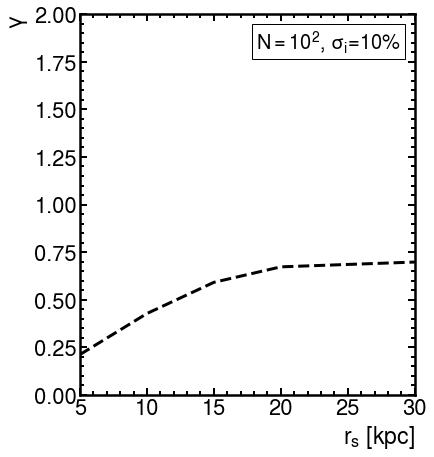

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 7))

path="/home/mariacst/exoplanets/exoplanets/python/gNFW/TSlogL/detect_signal/non_linear/data/"

ex="baseline"; f=1.; sigma=0.1; smooth=0.8
rs = [5., 10., 15., 20., 30.]

ax.plot(rs, gaussian_filter1d(gamma_detect, sigma=smooth), color="grey", lw=3., ls="-", label="detection")



#ax.text(10, 1.1, "nBDs=%i, f=1, $\sigma=$10"%(nBDs)+"$\%$",color=line_col,fontsize=small_fs,rotation=10)

ax.set_ylabel(r"$\gamma$", fontsize=23); ax.set_xlabel(r"$r_s$ [kpc]", fontsize=23)
ax.set_ylim(0., 2); ax.set_xlim(5., 30.)

from matplotlib.offsetbox import AnchoredText
text_box = AnchoredText((r"$N=10^{%i}$, $\sigma_i$=%i"                      
                            %(int(np.log10(nBDs)), int(sigma*100))            
                            + "$\% $"),                                         
                            frameon=True, loc=1, pad=0.2, prop=dict(size=20))   
plt.setp(text_box.patch, facecolor="white")                                 
ax.add_artist(text_box)  

plt.setp(ax.get_xticklabels(), fontsize=22)
plt.setp(ax.get_yticklabels(), fontsize=22)


ax.tick_params(which='major',direction="in",width=2.,length=7,right=True,top=True,pad=3)
ax.tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=True)
fig.savefig("detect_" + ex + "_nBDs%i_sigma%.1f_f%.1f.png"%(nBDs, sigma, f), bbox_inches="tight")
#ax.set_ylim(1., 1.5)

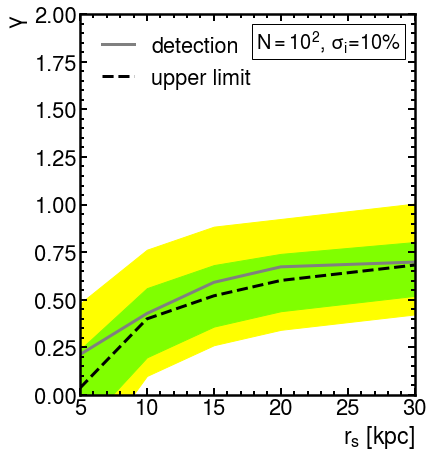

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(6, 7))

ex="baseline"; f=1.; sigma=0.1; smooth=0.8;
rs = [5., 10., 15., 20., 30.]

# Detection signal
ax.plot(rs, gaussian_filter1d(gamma_detect, sigma=smooth), color="grey", lw=3., ls="-", label="detection")

# upper limit
path="/home/mariacst/exoplanets/results/upper_limit/"
UL = []; gamma_UL_2sigma_minus=[]; gamma_UL_2sigma_plus=[]; gamma_UL_1sigma_minus=[]; gamma_UL_1sigma_plus=[]

for _rs in rs:
    data = np.genfromtxt(path + "UL_TSlogL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_rs%.1f_gNFW.dat"
                         %(nBDs, sigma, f, _rs), unpack=True)
    UL.append(np.median(data[1])); 
    gamma_UL_1sigma_minus.append(np.percentile(data[1], 15.85))
    gamma_UL_1sigma_plus.append(np.percentile(data[1], 84.15)); 
    gamma_UL_2sigma_plus.append(np.percentile(data[1], 97.7))
    gamma_UL_2sigma_minus.append(np.percentile(data[1], 2.30))

ax.plot(rs, UL, color="k", lw=3., ls="--", label="upper limit")

smooth=0.1
ax.fill_between(rs, gaussian_filter1d(gamma_UL_2sigma_minus, sigma=smooth), 
                y2=gaussian_filter1d(gamma_UL_1sigma_minus, sigma=smooth), color="#ffff00")
ax.fill_between(rs, gaussian_filter1d(gamma_UL_1sigma_plus, sigma=smooth),
                y2=gamma_UL_2sigma_plus, color="#ffff00")
ax.fill_between(rs, gaussian_filter1d(gamma_UL_1sigma_minus, sigma=smooth),
                y2=gaussian_filter1d(gamma_UL_1sigma_plus, sigma=smooth), color="#80ff00")


ax.set_ylabel(r"$\gamma$", fontsize=23); ax.set_xlabel(r"$r_s$ [kpc]", fontsize=23)
ax.set_ylim(0., 2); ax.set_xlim(5., 30.)

from matplotlib.offsetbox import AnchoredText
text_box = AnchoredText((r"$N=10^{%i}$, $\sigma_i$=%i"                      
                            %(int(np.log10(nBDs)), int(sigma*100))            
                            + "$\% $"),                                         
                            frameon=True, loc=1, pad=0.2, prop=dict(size=20))   
plt.setp(text_box.patch, facecolor="white")                                 
ax.add_artist(text_box)  

plt.setp(ax.get_xticklabels(), fontsize=22)
plt.setp(ax.get_yticklabels(), fontsize=22)
ax.legend(loc="upper left")

ax.tick_params(which='major',direction="in",width=2.,length=7,right=True,top=True,pad=3)
ax.tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=True)
fig.savefig("detect_UL_" + ex + "_nBDs%i_sigma%.1f_f%.1f.png"%(nBDs, sigma, f), bbox_inches="tight")